### 구글 드라이브 연결&라이브러리 임포트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q matplotlib koreanize-matplotlib openpyxl

import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix,f1_score, accuracy_score, mean_absolute_error, confusion_matrix
from sklearn.model_selection import cross_val_predict

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['axes.unicode_minus'] = False


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 24.1 MB/s eta 0:00:00


### 데이터 불러오기

In [3]:
df_work = pd.read_csv('/content/drive/MyDrive/[DS] 팀플/원본 데이터셋 모음/서울시 상권분석서비스(직장인구-행정동_직장).csv', encoding='cp949')
df_resi  = pd.read_csv('/content/drive/MyDrive/[DS] 팀플/원본 데이터셋 모음/서울시 상권분석서비스(상주인구-행정동_주거).csv',  encoding='cp949')
df_road  = pd.read_csv('/content/drive/MyDrive/[DS] 팀플/원본 데이터셋 모음/서울시 상권분석서비스(길단위인구-행정동_관광).csv', encoding='cp949')

In [4]:
df_q1 = pd.read_excel('/content/drive/MyDrive/[DS] 팀플/원본 데이터셋 모음/서울교통공사_지하철혼잡도정보1_20250331.xlsx')
df_q1['분기'] = '2025Q1'

df_q2 = pd.read_csv('/content/drive/MyDrive/[DS] 팀플/원본 데이터셋 모음/서울교통공사_지하철혼잡도정보_20250630_2분기.csv', encoding='cp949')
df_q2['분기'] = '2025Q2'

df_q3 = pd.read_csv('/content/drive/MyDrive/[DS] 팀플/원본 데이터셋 모음/서울교통공사_지하철혼잡도정보_20250930_3분기.csv', encoding='cp949')
df_q3['분기'] = '2025Q3'

df_q4 = pd.read_csv('/content/drive/MyDrive/[DS] 팀플/원본 데이터셋 모음/서울교통공사_지하철혼잡도정보_20251130_4분기.csv', encoding='cp949')
df_q4['분기'] = '2025Q4'

df_cong = pd.concat([df_q1, df_q2, df_q3, df_q4], ignore_index=True)


In [5]:
# 역번호 → 역명 매핑 (서울교통공사 공식 역번호)
STATION_NO = {
    '시청':201, '을지로입구':202, '을지로3가':203, '을지로4가':204,
    '동대문역사문화공원':205, '신당':206, '상왕십리':207, '왕십리':208,
    '한양대':209, '뚝섬':210, '성수':211, '건대입구':212,
    '구의':213, '강변':214, '잠실나루':215, '잠실':216,
    '잠실새내':217, '종합운동장':218, '삼성':219, '선릉':220,
    '역삼':221, '강남':222, '교대':223, '서초':224,
    '방배':225, '사당':226, '낙성대':227, '서울대입구':228,
    '봉천':229, '신림':230, '신대방':231, '구로디지털단지':232,
    '대림':233, '신도림':234, '문래':235, '영등포구청':236,
    '당산':237, '합정':238, '홍대입구':239, '신촌':240,
    '이대':241, '아현':242, '충정로':243,
    # 지선
    '신답':244, '용답':245, '신설동':246, '도림천':247,
    '까치산':248, '신정네거리':249, '용두':250, '양천구청':260,
    '성수E':9001, '상왕십리(지선)':9002, '동대문역사문화공원(지선)':9003,
}

# 역 → 행정동 매핑
LINE2_DONG = {
    '시청':'소공동', '을지로입구':'을지로동', '을지로3가':'을지로동',
    '을지로4가':'을지로동', '동대문역사문화공원':'신당동', '신당':'신당동',
    '상왕십리':'행당2동', '왕십리':'왕십리2동', '한양대':'행당1동',
    '뚝섬':'성수1가1동', '성수':'성수1가2동', '건대입구':'화양동',
    '구의':'구의1동', '강변':'구의3동', '잠실나루':'자양4동',
    '잠실':'잠실본동', '잠실새내':'잠실4동', '종합운동장':'잠실2동',
    '삼성':'삼성1동', '선릉':'역삼2동', '역삼':'역삼1동',
    '강남':'역삼1동', '교대':'서초3동', '서초':'서초1동',
    '방배':'방배본동', '사당':'사당1동', '낙성대':'낙성대동',
    '서울대입구':'대학동', '봉천':'청룡동', '신림':'신림동',
    '신대방':'신대방1동', '구로디지털단지':'구로3동', '대림':'대림2동',
    '신도림':'신도림동', '문래':'문래동', '영등포구청':'영등포본동',
    '당산':'당산2동', '합정':'합정동', '홍대입구':'서교동',
    '신촌':'신촌동', '이대':'대흥동', '아현':'아현동',
    '충정로':'충현동',
    # 지선
    '신답':'용답동', '용답':'용답동', '신설동':'용신동',
    '도림천':'도림동', '까치산':'신월3동', '신정네거리':'신정4동',
    '용두':'용신동', '양천구청':'신정1동',
    '성수E':'성수2가1동', '상왕십리(지선)':'행당2동',
    '동대문역사문화공원(지선)':'신당동',
}

# 역번호 → 행정동 매핑
NO_DONG = {no: LINE2_DONG[name] for name, no in STATION_NO.items()}
station_dong_df = pd.DataFrame(list(NO_DONG.items()), columns=['역번호','행정동'])


# EDA

## 1. Work class data
>  행/열 수 ·  결측치 총 개수 확인 · 수치형 데이터 기초 통계량 · 이상치 탐지 · 노이즈(문자/비정상값) · 중복 행

In [6]:
print(f"[Work class] data : {df_work.shape[0]:,}rows × {df_work.shape[1]}cols\n")

print(f"[missing values]: {df_work.isnull().sum().sum()}")

print("\n[Outlier Detection] IQR Criterion — Top 5 Numerical Columns\n")
numeric_df = df_work.select_dtypes(include=['number'])

target_columns = numeric_df.columns[2:7]
for col in target_columns:
    q1 = df_work[col].quantile(0.25)
    q3 = df_work[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df_work[(df_work[col] < lower) | (df_work[col] > upper)]
    outliers_cnt = len(outliers)

    min_val = int(df_work[col].min())
    max_val = int(df_work[col].max())

    print(f"  · {col}: {outliers_cnt:,}개  (범위: {min_val:,} ~ {max_val:,})")

print(f"[Duplicate rows] {df_work.duplicated().sum()}")

print("[Data preview]\n")
display(df_work.head(3))

print("[numeric value statistical summary]\n")
display(df_work.describe())


[Work class] data : 11,592rows × 24cols

[missing values]: 0

[Outlier Detection] IQR Criterion — Top 5 Numerical Columns

  · 총_직장_인구_수: 1,641개  (범위: 3 ~ 250,897)
  · 남성_직장_인구_수: 1,509개  (범위: 0 ~ 178,057)
  · 여성_직장_인구_수: 1,729개  (범위: 3 ~ 82,396)
  · 연령대_10_직장_인구_수: 2,287개  (범위: 0 ~ 1,676)
  · 연령대_20_직장_인구_수: 1,535개  (범위: 0 ~ 46,135)
[Duplicate rows] 0
[Data preview]



,기준_년분기_코드,행정동_코드,행정동_코드_명,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,연령대_30_직장_인구_수,연령대_40_직장_인구_수,...,남성연령대_30_직장_인구_수,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수
0,20254,11740700,둔촌2동,2489,1120,1369,0,472,661,548,...,274,274,245,200,0,345,387,274,274,89
1,20254,11740685,길동,9734,4931,4803,0,1332,1956,2232,...,1048,1192,1095,1095,0,831,908,1040,1310,714
2,20254,11740660,성내3동,3676,2235,1441,0,497,837,936,...,537,573,440,426,0,238,300,363,333,207


[numeric value statistical summary]



,기준_년분기_코드,행정동_코드,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,연령대_30_직장_인구_수,연령대_40_직장_인구_수,연령대_50_직장_인구_수,...,남성연령대_30_직장_인구_수,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수
count,11592.00000,1.159200e+04,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,...,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000,11592.000000
mean,20222.50000,1.142888e+07,9423.703157,5777.897602,3645.805556,22.743616,1680.980849,2680.709541,2403.931763,1794.761128,...,1635.092736,1591.181159,1190.590235,576.300466,13.289769,905.701691,1045.616805,812.750604,604.170894,264.275794
std,20.03209,1.908668e+05,22301.430243,14247.021299,8342.989003,103.714023,4416.680923,7157.084010,5814.857546,3845.486483,...,4586.240471,4101.800866,2778.268782,937.655904,61.653871,2334.105502,2674.131479,1799.221885,1263.233573,519.560564
min,20191.00000,1.111052e+07,3.000000,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,20203.75000,1.126061e+07,1070.000000,584.000000,453.000000,0.000000,106.750000,210.000000,269.000000,266.000000,...,109.000000,146.000000,145.000000,114.000000,0.000000,62.000000,97.000000,119.000000,110.000000,34.000000
50%,20222.50000,1.144058e+07,2245.000000,1328.000000,912.000000,0.000000,287.000000,503.500000,556.000000,515.000000,...,284.000000,316.500000,309.000000,232.000000,0.000000,151.000000,208.000000,224.000000,202.000000,93.500000
75%,20241.25000,1.159065e+07,6356.000000,3937.000000,2434.250000,2.000000,1049.000000,1558.000000,1574.250000,1314.000000,...,979.250000,1033.000000,852.000000,550.250000,0.000000,563.000000,618.000000,569.000000,499.250000,240.000000
max,20254.00000,1.174070e+07,250897.000000,178057.000000,82396.000000,1676.000000,46135.000000,89946.000000,64522.000000,38476.000000,...,64291.000000,49833.000000,30627.000000,8442.000000,959.000000,21282.000000,25655.000000,18096.000000,16181.000000,6093.000000


>행정동별 분석

In [7]:
latest_q_w = df_work['기준_년분기_코드'].max()
df_w = df_work[df_work['기준_년분기_코드'] == latest_q_w].copy()

age_cols_w = ['연령대_10_직장_인구_수','연령대_20_직장_인구_수','연령대_30_직장_인구_수',
              '연령대_40_직장_인구_수','연령대_50_직장_인구_수','연령대_60_이상_직장_인구_수']

df_w_grp = df_w.groupby('행정동_코드_명')[['총_직장_인구_수','남성_직장_인구_수','여성_직장_인구_수'] + age_cols_w].mean()
df_w_grp = df_w_grp.sort_values('총_직장_인구_수', ascending=False)

print(f'기준 분기: {latest_q_w}')
print(df_w_grp[['총_직장_인구_수', '남성_직장_인구_수', '여성_직장_인구_수']].round(0).to_string())

기준 분기: 20254
             총_직장_인구_수  남성_직장_인구_수  여성_직장_인구_수
행정동_코드_명                                      
여의동           250897.0    178057.0     72840.0
역삼1동          202016.0    119620.0     82396.0
삼성1동          189339.0    127736.0     61603.0
명동            120704.0     69872.0     50832.0
종로1?2?3?4가동   109733.0     60491.0     49242.0
가산동           106107.0     69840.0     36267.0
대치2동          102922.0     57561.0     45361.0
소공동            92258.0     48973.0     43285.0
도곡2동           84833.0     58013.0     26820.0
잠실6동           83532.0     44510.0     39022.0
문정2동           78185.0     49174.0     29011.0
삼성2동           70662.0     40645.0     30017.0
회현동            69985.0     43262.0     26723.0
서초2동           66239.0     43996.0     22243.0
문래동            65200.0     47342.0     17858.0
구로3동           62687.0     41149.0     21538.0
한강로동           58448.0     28867.0     29581.0
청담동            58171.0     33367.0     24804.0
논현2동           57007.0     36529.0     20478.0


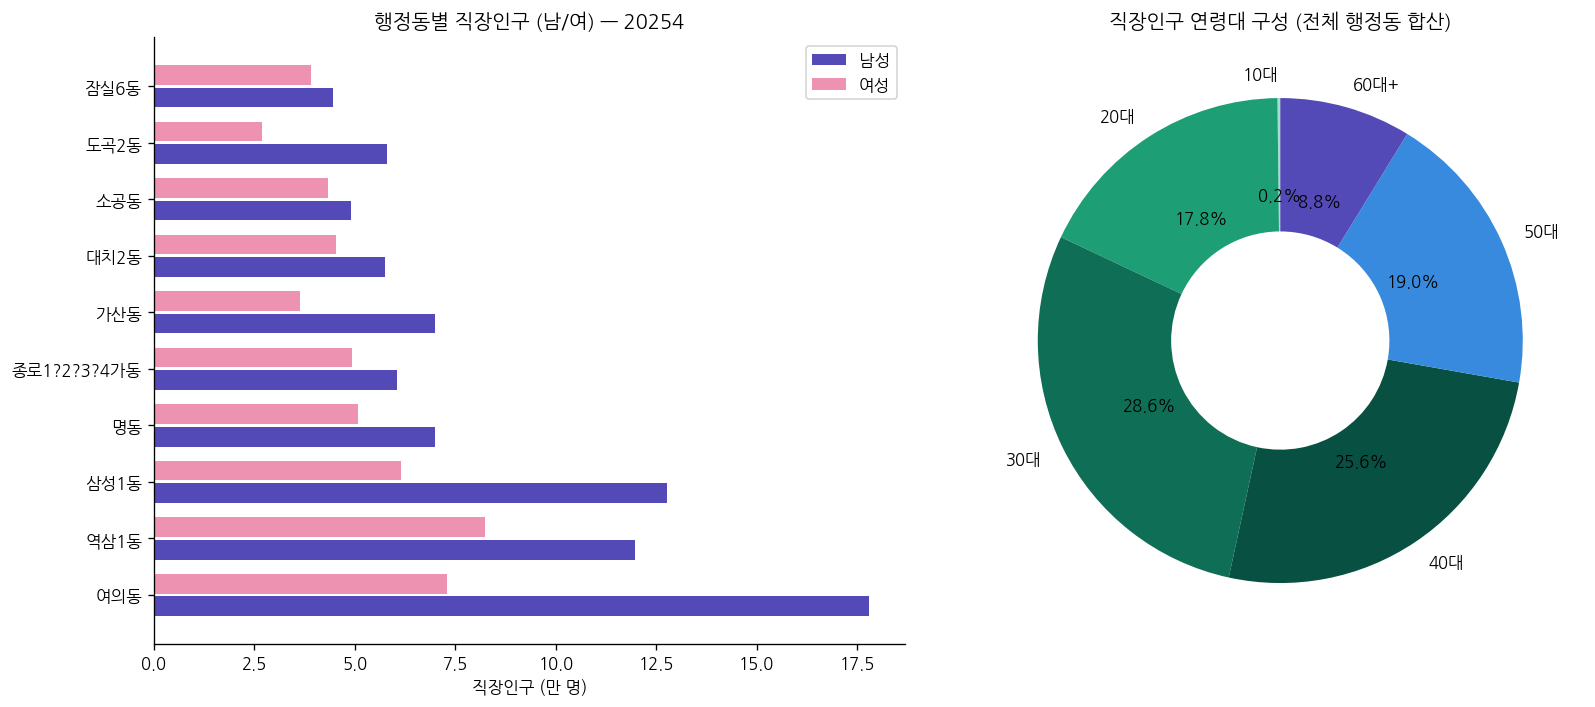

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10 = df_w_grp.head(10)
y = np.arange(len(top10))
axes[0].barh(y - 0.2, top10['남성_직장_인구_수']/1e4, height=0.35, color='#534AB7', label='남성')
axes[0].barh(y + 0.2, top10['여성_직장_인구_수']/1e4, height=0.35, color='#ED93B1', label='여성')
axes[0].set_yticks(y)
axes[0].set_yticklabels(top10.index)
axes[0].set_xlabel('직장인구 (만 명)')
axes[0].set_title(f'행정동별 직장인구 (남/여) — {latest_q_w}', fontsize=12)
axes[0].legend()

age_labels_w = ['10대','20대','30대','40대','50대','60대+']
age_totals_w = df_w_grp[age_cols_w].sum()
colors_age = ['#9FE1CB','#1D9E75','#0F6E56','#085041','#378ADD','#534AB7']
wedges, texts, autotexts = axes[1].pie(
    age_totals_w, labels=age_labels_w, colors=colors_age,
    autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.55}
)
axes[1].set_title('직장인구 연령대 구성 (전체 행정동 합산)', fontsize=12)

plt.tight_layout()
plt.show()


## Residents data
>  행/열 수 ·  결측치 총 개수 확인 · 수치형 데이터 기초 통계량 · 이상치 탐지 · 노이즈(문자/비정상값) · 중복 행

In [9]:
print(f"[Resident] data : {df_resi.shape[0]:,} rows × {df_resi.shape[1]} cols\n")

print(f"[missing values]: {df_resi.isnull().sum().sum()}\n")
print("[Outlier Detection] IQR Criterion — Top 5 Numerical Columns\n")

numeric_df_r = df_resi.select_dtypes(include=['number'])
target_columns_r = numeric_df_r.columns[2:7]

for col in target_columns_r:
    q1 = df_resi[col].quantile(0.25)
    q3 = df_resi[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df_resi[(df_resi[col] < lower) | (df_resi[col] > upper)]
    outliers_cnt = len(outliers)

    min_val = int(df_resi[col].min())
    max_val = int(df_resi[col].max())

    print(f"  · {col}: {outliers_cnt:,}개  (범위: {min_val:,} ~ {max_val:,})")

print(f"\n[Duplicate rows] {df_resi.duplicated().sum()}\n")

print("[Data preview]\n")
display(df_resi.head(3))

print("\n[numeric value statistical summary]\n")
display(df_resi.describe())

[Resident] data : 11,879 rows × 27 cols

[missing values]: 0

[Outlier Detection] IQR Criterion — Top 5 Numerical Columns

  · 총_상주인구_수: 200개  (범위: 16 ~ 60,227)
  · 남성_상주인구_수: 149개  (범위: 10 ~ 28,431)
  · 여성_상주인구_수: 215개  (범위: 6 ~ 31,796)
  · 연령대_10_상주인구_수: 556개  (범위: 2 ~ 13,709)
  · 연령대_20_상주인구_수: 290개  (범위: 0 ~ 11,517)

[Duplicate rows] 0

[Data preview]



,기준_년분기_코드,행정동_코드,행정동_코드_명,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,연령대_10_상주인구_수,연령대_20_상주인구_수,연령대_30_상주인구_수,연령대_40_상주인구_수,...,남성연령대_60_이상_상주인구_수,여성연령대_10_상주인구_수,여성연령대_20_상주인구_수,여성연령대_30_상주인구_수,여성연령대_40_상주인구_수,여성연령대_50_상주인구_수,여성연령대_60_이상_상주인구_수,총_가구_수,아파트_가구_수,비_아파트_가구_수
0,20254,11740700,둔촌2동,24228,11861,12367,3360,3110,3688,3495,...,3071,1596,1578,1814,1743,2043,3593,10426,0,10426
1,20254,11740690,둔촌1동,16,10,6,2,0,1,5,...,5,0,0,0,3,1,2,11,0,11
2,20254,11740685,길동,44395,21594,22801,4611,6297,7127,6419,...,5882,2200,3351,3490,3129,3671,6960,21799,0,21799



[numeric value statistical summary]



,기준_년분기_코드,행정동_코드,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,연령대_10_상주인구_수,연령대_20_상주인구_수,연령대_30_상주인구_수,연령대_40_상주인구_수,연령대_50_상주인구_수,...,남성연령대_60_이상_상주인구_수,여성연령대_10_상주인구_수,여성연령대_20_상주인구_수,여성연령대_30_상주인구_수,여성연령대_40_상주인구_수,여성연령대_50_상주인구_수,여성연령대_60_이상_상주인구_수,총_가구_수,아파트_가구_수,비_아파트_가구_수
count,11879.000000,1.187900e+04,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,...,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000,11879.000000
mean,20222.553919,1.143359e+07,22419.640963,10910.762943,11508.878020,3154.642478,3205.099167,3436.929540,3533.199175,3569.309117,...,2507.737604,1535.340854,1645.423436,1720.048489,1780.358784,1814.982574,3012.723882,10315.723630,303.802340,10011.921290
std,20.008609,1.916069e+05,9201.424871,4448.523648,4780.318006,1929.677657,1586.158931,1619.225626,1684.792457,1485.378738,...,1032.793498,939.739762,866.061186,828.639067,890.811885,770.992979,1261.260324,4181.445529,1258.313813,4307.885166
min,20191.000000,1.111052e+07,16.000000,10.000000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,...,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,11.000000,0.000000,11.000000
25%,20204.000000,1.126066e+07,16449.000000,7937.000000,8503.000000,1842.000000,2130.000000,2330.500000,2434.000000,2568.000000,...,1802.000000,899.000000,1063.000000,1162.000000,1188.500000,1303.000000,2157.500000,7469.000000,0.000000,7154.000000
50%,20223.000000,1.144063e+07,21787.000000,10610.000000,11140.000000,2784.000000,2979.000000,3262.000000,3335.000000,3466.000000,...,2410.000000,1343.000000,1502.000000,1608.000000,1659.000000,1768.000000,2877.000000,10008.000000,0.000000,9671.000000
75%,20242.000000,1.159068e+07,27745.000000,13583.000000,14308.000000,4032.000000,4094.000000,4401.000000,4414.000000,4522.000000,...,3119.000000,1964.000000,2109.000000,2194.000000,2244.000000,2308.000000,3772.000000,12775.500000,0.000000,12605.000000
max,20254.000000,1.174070e+07,60227.000000,28431.000000,31796.000000,13709.000000,11517.000000,11831.000000,11961.000000,9883.000000,...,6767.000000,6704.000000,6391.000000,5586.000000,6138.000000,4967.000000,7894.000000,28118.000000,14283.000000,28118.000000


> 행정동별 분석

In [10]:
latest_q_r = df_resi['기준_년분기_코드'].max()
df_r = df_resi[df_resi['기준_년분기_코드'] == latest_q_r].copy()

age_cols_r = ['연령대_10_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
              '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수']

df_r_grp = df_r.groupby('행정동_코드_명')[
    ['총_상주인구_수', '남성_상주인구_수', '여성_상주인구_수',
     '총_가구_수', '아파트_가구_수', '비_아파트_가구_수'] + age_cols_r
].sum().sort_values('총_상주인구_수', ascending=False)

df_r_grp['아파트_가구_비율'] = df_r_grp['아파트_가구_수'] / df_r_grp['총_가구_수'] * 100

print(f'기준 분기: {latest_q_r}')
display(df_r_grp[['총_상주인구_수', '총_가구_수', '아파트_가구_수', '아파트_가구_비율']].round(1).head(10))

기준 분기: 20254


,총_상주인구_수,총_가구_수,아파트_가구_수,아파트_가구_비율
행정동_코드_명,,,,
진관동,54368,21360,0,0.0
화곡1동,50743,28118,0,0.0
신정3동,49523,19703,0,0.0
독산1동,45720,24569,0,0.0
세곡동,45513,19381,0,0.0
위례동,44857,14702,0,0.0
상도1동,44464,22704,0,0.0
길동,44395,21799,0,0.0
강일동,44257,17658,0,0.0


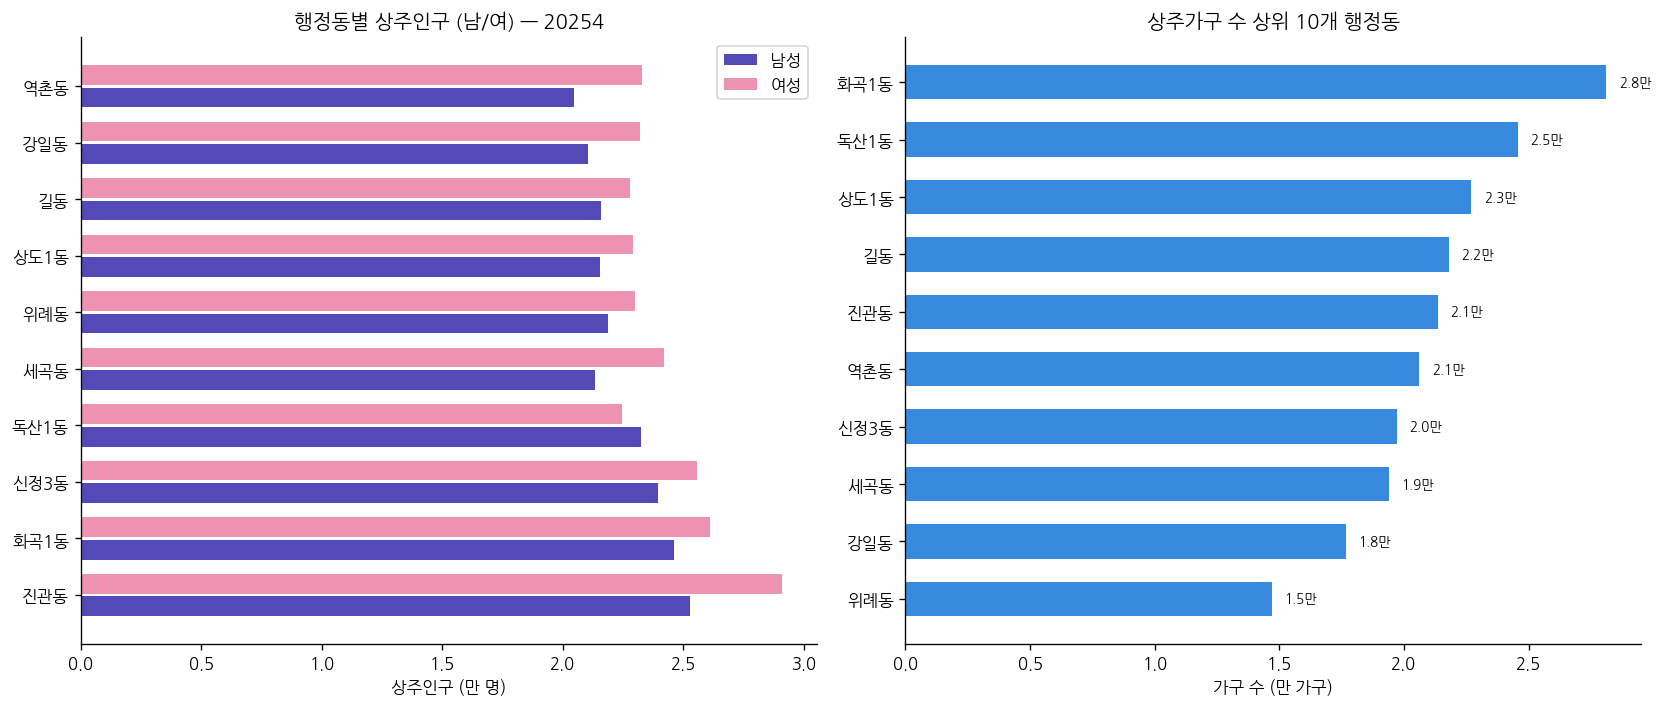

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10r = df_r_grp.head(10)
y = np.arange(len(top10r))

axes[0].barh(y - 0.2, top10r['남성_상주인구_수'] / 1e4, height=0.35, color='#534AB7', label='남성')
axes[0].barh(y + 0.2, top10r['여성_상주인구_수'] / 1e4, height=0.35, color='#ED93B1', label='여성')
axes[0].set_yticks(y)
axes[0].set_yticklabels(top10r.index)
axes[0].set_xlabel('상주인구 (만 명)')
axes[0].set_title(f'행정동별 상주인구 (남/여) — {latest_q_r}', fontsize=12) # 자치구별 -> 행정동별로 타이틀 수정
axes[0].legend()

top10_household = df_r_grp.head(10).sort_values('총_가구_수', ascending=True)
bars = axes[1].barh(top10_household.index, top10_household['총_가구_수']/1e4, color='#378ADD', height=0.6)
axes[1].set_title('상주가구 수 상위 10개 행정동', fontsize=12)
axes[1].set_xlabel('가구 수 (만 가구)')
for bar, val in zip(bars, top10_household['총_가구_수'] / 1e4):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}만', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Road data
>  행/열 수 ·  결측치 총 개수 확인 · 수치형 데이터 기초 통계량 · 이상치 탐지 · 노이즈(문자/비정상값) · 중복 행

In [12]:
print(f"[Road] data : {df_road.shape[0]:,} rows × {df_road.shape[1]} cols\n")

print(f"[missing values]: {df_road.isnull().sum().sum()}")

print("\n[Outlier Detection] IQR Criterion — Top 5 Numerical Columns\n")

numeric_df_rd = df_road.select_dtypes(include=['number'])
target_columns_rd = numeric_df_rd.columns[2:7]

for col in target_columns_rd:
    q1 = df_road[col].quantile(0.25)
    q3 = df_road[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df_road[(df_road[col] < lower) | (df_road[col] > upper)]
    outliers_cnt = len(outliers)

    min_val = int(df_road[col].min())
    max_val = int(df_road[col].max())

    print(f"  · {col}: {outliers_cnt:,}개  (범위: {min_val:,} ~ {max_val:,})")

print(f"[Duplicate rows] {df_road.duplicated().sum()}")

print("[Data preview]\n")
display(df_road.head(3))

print("[numeric value statistical summary]\n")
display(df_road.describe())

[Road] data : 11,900 rows × 25 cols

[missing values]: 0

[Outlier Detection] IQR Criterion — Top 5 Numerical Columns

  · 총_유동인구_수: 314개  (범위: 7,864 ~ 26,535,149)
  · 남성_유동인구_수: 307개  (범위: 3,936 ~ 12,299,161)
  · 여성_유동인구_수: 316개  (범위: 3,876 ~ 14,235,988)
  · 연령대_10_유동인구_수: 293개  (범위: 1,598 ~ 4,018,667)
  · 연령대_20_유동인구_수: 600개  (범위: 745 ~ 6,648,642)
[Duplicate rows] 0
[Data preview]



,기준_년분기_코드,행정동_코드,행정동_코드_명,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,...,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
0,20254,11740700,둔촌2동,6419131,2978649,3440482,1227181,725811,959328,1018460,...,701540,1000801,849191,917060,910329,918759,909647,912575,910150,940610
1,20254,11740690,둔촌1동,29398,13580,15819,6767,2325,4159,5594,...,3184,4561,3847,4120,4125,4147,4149,4183,4284,4391
2,20254,11740685,길동,18073434,8191172,9882261,2453568,2170829,2912958,2965881,...,2076482,3011274,2433431,2550715,2551044,2557744,2563428,2573696,2624616,2652190


[numeric value statistical summary]



,기준_년분기_코드,행정동_코드,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,연령대_50_유동인구_수,...,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
count,11900.000000,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,...,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04,1.190000e+04
mean,20222.500000,1.143342e+07,5.589679e+06,2.634967e+06,2.954711e+06,8.236221e+05,8.882928e+05,9.282758e+05,9.050851e+05,8.173363e+05,...,6.775978e+05,9.267501e+05,7.123089e+05,8.002329e+05,8.018280e+05,8.029197e+05,8.018369e+05,7.998150e+05,7.913998e+05,7.916465e+05
std,20.032067,1.915086e+05,2.985699e+06,1.431189e+06,1.569794e+06,4.528881e+05,7.124162e+05,6.040373e+05,5.078142e+05,4.340483e+05,...,4.241068e+05,5.260638e+05,3.727476e+05,4.320277e+05,4.369082e+05,4.376641e+05,4.375343e+05,4.360725e+05,4.165884e+05,4.110003e+05
min,20191.000000,1.111052e+07,7.864000e+03,3.936000e+03,3.876000e+03,1.598000e+03,7.450000e+02,1.007000e+03,1.253000e+03,1.185000e+03,...,1.050000e+03,1.346000e+03,8.900000e+02,1.109000e+03,1.126000e+03,1.135000e+03,1.128000e+03,1.122000e+03,1.084000e+03,1.126000e+03
25%,20203.750000,1.126066e+07,3.485422e+06,1.628892e+06,1.857638e+06,5.110478e+05,4.260715e+05,5.108222e+05,5.611070e+05,5.193790e+05,...,3.951890e+05,5.577730e+05,4.458730e+05,4.976528e+05,4.966625e+05,4.967942e+05,4.960395e+05,4.943055e+05,4.972490e+05,5.005245e+05
50%,20222.500000,1.144063e+07,5.285438e+06,2.480472e+06,2.773212e+06,7.427890e+05,7.323810e+05,8.336555e+05,8.361135e+05,7.510515e+05,...,6.068450e+05,8.573355e+05,6.712675e+05,7.570660e+05,7.571275e+05,7.581590e+05,7.561925e+05,7.526210e+05,7.423015e+05,7.442310e+05
75%,20241.250000,1.159068e+07,7.018338e+06,3.319704e+06,3.734220e+06,1.073759e+06,1.109894e+06,1.219635e+06,1.134074e+06,1.026832e+06,...,8.512722e+05,1.164212e+06,9.118442e+05,1.006341e+06,1.006305e+06,1.006404e+06,1.006226e+06,1.004134e+06,1.002043e+06,1.010366e+06
max,20254.000000,1.174070e+07,2.653515e+07,1.229916e+07,1.423599e+07,4.018667e+06,6.648642e+06,6.303219e+06,5.641553e+06,4.135114e+06,...,4.313064e+06,4.599656e+06,2.656476e+06,4.007767e+06,4.136169e+06,4.179721e+06,4.102933e+06,4.012614e+06,3.140105e+06,2.958925e+06


> 행정동별 분석

In [13]:
latest_q_d = df_road['기준_년분기_코드'].max()
df_d = df_road[df_road['기준_년분기_코드'] == latest_q_d].copy()

time_slot_cols = ['시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
                  '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
                  '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수']

day_cols = ['월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수',
            '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수']

df_d_grp = df_d.groupby('행정동_코드_명')[['총_유동인구_수'] + time_slot_cols + day_cols].mean()
df_d_grp = df_d_grp.sort_values('총_유동인구_수', ascending=False)

print(f'기준 분기: {latest_q_d}')
display(df_d_grp[['총_유동인구_수']].round(0).head(10))

기준 분기: 20254


,총_유동인구_수
행정동_코드_명,
북아현동,26535149.0
역삼1동,19879130.0
길동,18073434.0
서교동,17215576.0
화곡1동,15716871.0
용신동,13908963.0
종로1?2?3?4가동,13824388.0
대조동,12420998.0
서초3동,12120750.0


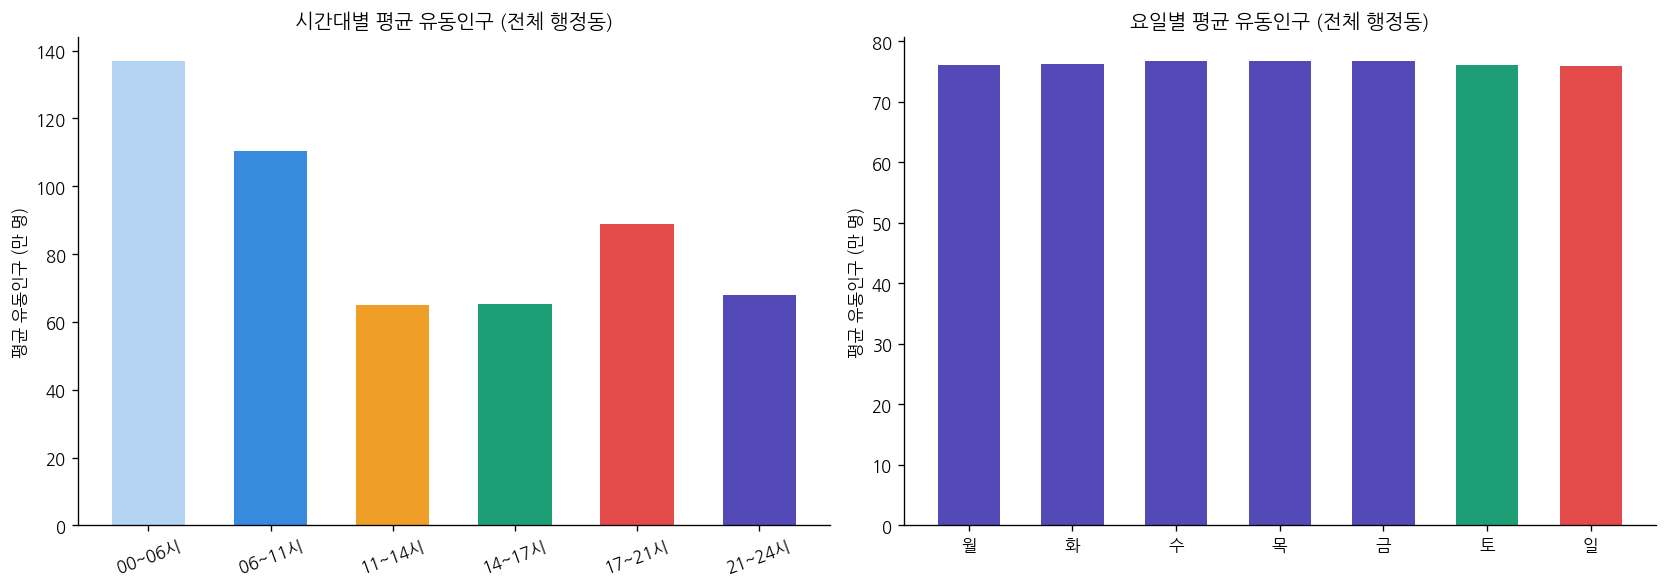

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_labels = ['00~06시','06~11시','11~14시','14~17시','17~21시','21~24시']
time_vals = df_d[time_slot_cols].mean()
bar_colors_t = ['#B5D4F4','#378ADD','#EF9F27','#1D9E75','#E24B4A','#534AB7']
axes[0].bar(time_labels, time_vals / 1e4, color=bar_colors_t, width=0.6)
axes[0].set_title('시간대별 평균 유동인구 (전체 행정동)', fontsize=12)
axes[0].set_ylabel('평균 유동인구 (만 명)')
axes[0].tick_params(axis='x', rotation=20)

day_labels = ['월','화','수','목','금','토','일']
day_vals = df_d[day_cols].mean()
bar_colors_d = ['#534AB7']*5 + ['#1D9E75','#E24B4A']
axes[1].bar(day_labels, day_vals / 1e4, color=bar_colors_d, width=0.6)
axes[1].set_title('요일별 평균 유동인구 (전체 행정동)', fontsize=12)
axes[1].set_ylabel('평균 유동인구 (만 명)')

plt.tight_layout()
plt.show()


##  Congestion data
>  행/열 수 ·  결측치 총 개수 확인 · 수치형 데이터 기초 통계량 · 이상치 탐지 · 노이즈(문자/비정상값) · 중복 행


In [15]:
print(f"[Congestion] data : {df_cong.shape[0]:,} rows × {df_cong.shape[1]} cols\n")

print(f"[missing values]: {df_cong.isnull().sum().sum()}")

print("\n[Outlier Detection] IQR Criterion — Top 5 Numerical Columns\n")

numeric_df_cg = df_cong.select_dtypes(include=['number'])
target_columns_cg = numeric_df_cg.columns[2:7]

for col in target_columns_cg:
    q1 = df_cong[col].quantile(0.25)
    q3 = df_cong[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df_cong[(df_cong[col] < lower) | (df_cong[col] > upper)]
    outliers_cnt = len(outliers)

    min_val = int(df_cong[col].min())
    max_val = int(df_cong[col].max())

    print(f"  · {col}: {outliers_cnt:,}개  (범위: {min_val:,} ~ {max_val:,})")

print(f"[Duplicate rows] {df_cong.duplicated().sum()}")

print("[Data preview]\n")
display(df_cong.head(3))

print("[numeric value statistical summary]\n")
display(df_cong.describe())

[Congestion] data : 6,675 rows × 46 cols

[missing values]: 6121

[Outlier Detection] IQR Criterion — Top 5 Numerical Columns

  · 5시30분: 399개  (범위: 0 ~ 122)
  · 6시00분: 381개  (범위: 0 ~ 76)
  · 6시30분: 507개  (범위: 0 ~ 83)
  · 7시00분: 623개  (범위: 0 ~ 122)
  · 7시30분: 659개  (범위: 0 ~ 141)
[Duplicate rows] 0
[Data preview]



,연번,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,...,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분,분기
0,1.0,평일,1,158,청량리,상선,7.2,6.9,4.5,8.3,...,26.1,28.2,24.5,23.0,22.2,21.7,14.9,8.5,0.0,2025Q1
1,2.0,평일,1,157,제기동,상선,7.6,8.7,6.5,8.7,...,26.0,34.8,27.5,25.7,25.4,24.2,16.8,11.6,0.0,2025Q1
2,3.0,평일,1,156,신설동,상선,6.7,11.2,7.2,9.6,...,26.8,36.3,28.6,26.6,26.1,25.2,16.1,12.6,0.0,2025Q1


[numeric value statistical summary]



,연번,역번호,5시30분,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
count,1662.00000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,...,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,6675.000000,5567.000000
mean,831.50000,1705.048090,15.744719,15.924464,15.403491,19.924539,25.586801,32.225693,30.637034,30.646547,...,26.032330,26.741124,27.396914,26.581079,27.200704,23.929753,20.382801,14.404749,4.192030,2.091701
std,479.92239,1437.030613,14.529042,11.544618,12.875577,19.470250,25.576590,29.258652,24.532970,22.033009,...,15.275664,16.434839,17.293517,18.091313,18.560506,16.188807,14.509923,11.044481,6.454579,3.709612
min,1.00000,150.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,416.25000,317.000000,6.800000,8.400000,7.400000,8.100000,9.500000,12.800000,14.500000,15.900000,...,14.600000,14.600000,14.350000,13.100000,13.700000,11.800000,9.600000,6.300000,0.000000,0.000000
50%,831.50000,2529.000000,11.500000,13.100000,11.600000,12.800000,15.600000,21.400000,23.100000,24.900000,...,24.100000,24.200000,25.000000,23.700000,23.900000,20.900000,17.400000,11.900000,0.000000,0.000000
75%,1246.75000,2645.000000,20.300000,20.100000,18.900000,24.200000,32.000000,41.900000,39.300000,39.600000,...,35.150000,36.800000,37.800000,36.200000,36.400000,32.900000,28.300000,20.100000,7.200000,3.000000
max,1662.00000,9006.000000,122.900000,76.300000,83.800000,122.300000,141.600000,159.400000,151.900000,147.400000,...,80.500000,93.000000,119.800000,164.300000,161.900000,120.100000,95.800000,87.400000,50.300000,23.800000


>  2호선 필터링 & 역사 커버리지 확인

In [16]:
df_line2 = df_cong[df_cong['호선'] == '2호선'].copy()
time_cols = [c for c in df_cong.columns if '시' in c and '분' in c]

# 데이터상 2호선 역 vs 공식 역 비교
data_stations = set(df_line2['출발역'].unique())
official_stations = set(STATION_NO)
in_both = data_stations & official_stations
only_in_data = data_stations - official_stations
only_official = official_stations - data_stations

print(f'[2호선 역사 커버리지]')
print(f'  공식 역 수      : {len(official_stations)}개')
print(f'  데이터 역 수    : {len(data_stations)}개')
print(f'  일치(커버)      : {len(in_both)}개')
print(f'  데이터에만 존재 : {sorted(only_in_data)}')
print(f'  데이터에 누락   : {sorted(only_official)}')
print()
print(f'[분기별 2호선 데이터 건수]')
print(df_line2.groupby(['분기','요일구분']).size().unstack(fill_value=0))


[2호선 역사 커버리지]
  공식 역 수      : 54개
  데이터 역 수    : 52개
  일치(커버)      : 51개
  데이터에만 존재 : ['신촌(지하)']
  데이터에 누락   : ['동대문역사문화공원(지선)', '상왕십리(지선)', '신촌']

[분기별 2호선 데이터 건수]
요일구분    일요일  토요일   평일
분기                   
2025Q2  108  108  108
2025Q3  108  108  108
2025Q4  108  108  108


> 호선별 시간대별 평균 혼잡도 (호선별 평균 혼잡도 = 해당 시간대 각 역사의 혼잡도를 평균 낸 값)

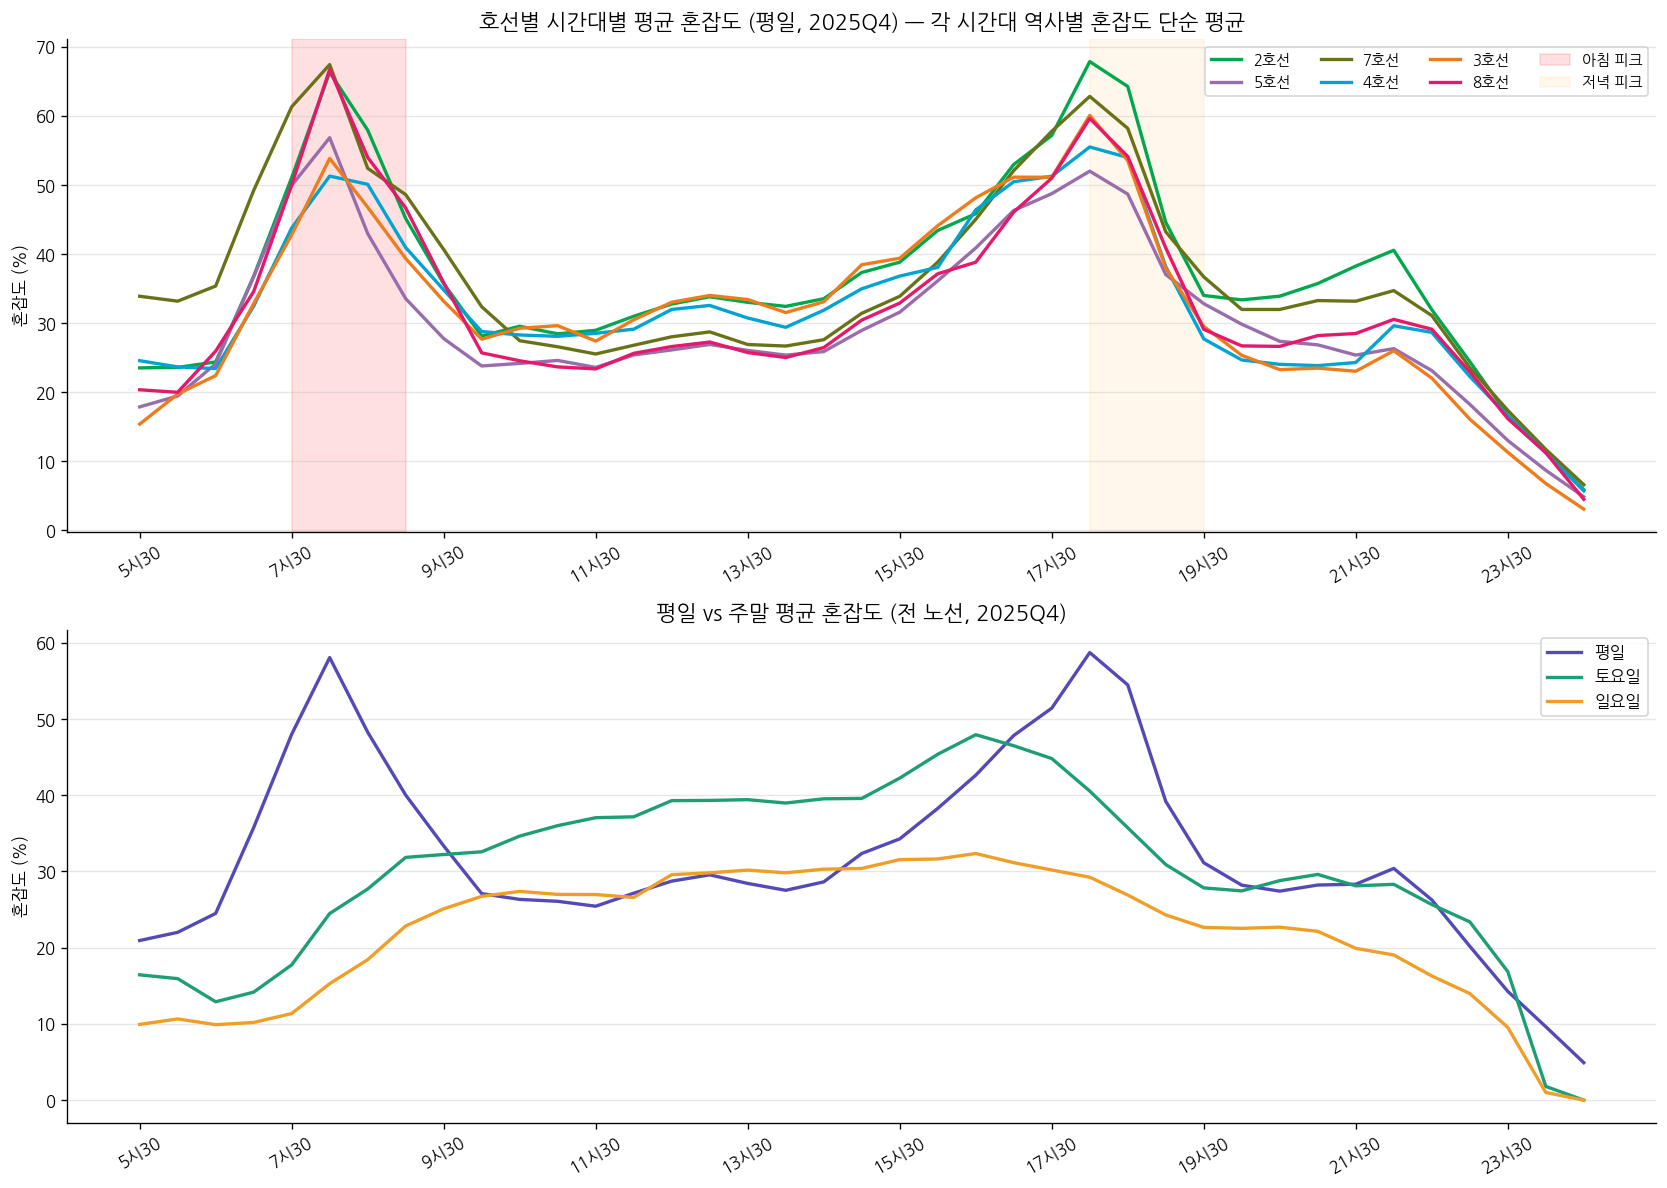

In [17]:
df_q4_weekday = df_cong[(df_cong['분기']=='2025Q4') & (df_cong['요일구분']=='평일')].copy()
time_labels_full = [c.replace('분','') for c in time_cols]

main_lines = ['2호선','5호선','7호선','4호선','3호선','8호선']
colors_lines = ['#00A84D','#996CAC','#697217','#00A3D2','#EF7C1C','#E6186C']

hourly = df_q4_weekday.groupby('호선')[time_cols].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for line, color in zip(main_lines, colors_lines):
    if line in hourly.index:
        axes[0].plot(time_labels_full, hourly.loc[line].values,
                     label=line, color=color, linewidth=2)

axes[0].axvspan(time_labels_full.index('7시30'), time_labels_full.index('9시00'),
                alpha=0.12, color='red', label='아침 피크')
axes[0].axvspan(time_labels_full.index('18시00'), time_labels_full.index('19시30'),
                alpha=0.08, color='orange', label='저녁 피크')
axes[0].set_title('호선별 시간대별 평균 혼잡도 (평일, 2025Q4) — 각 시간대 역사별 혼잡도 단순 평균', fontsize=13)
axes[0].set_ylabel('혼잡도 (%)')
axes[0].set_xticks(range(0, len(time_labels_full), 4))
axes[0].set_xticklabels(time_labels_full[::4], rotation=30)
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

compare = df_cong[df_cong['분기']=='2025Q4'].groupby('요일구분')[time_cols].mean()
day_types = [d for d in ['평일','토요일','일요일'] if d in compare.index]
day_colors = ['#534AB7','#1D9E75','#EF9F27']
for day, color in zip(day_types, day_colors):
    axes[1].plot(time_labels_full, compare.loc[day].values,
                 label=day, color=color, linewidth=2)

axes[1].set_title('평일 vs 주말 평균 혼잡도 (전 노선, 2025Q4)', fontsize=13)
axes[1].set_ylabel('혼잡도 (%)')
axes[1].set_xticks(range(0, len(time_labels_full), 4))
axes[1].set_xticklabels(time_labels_full[::4], rotation=30)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

> 2호선 역사별 시간대별 혼잡도:  대표역 1개 (직관 부합: 사당) vs 비대표역 1개 (직관 부합 X: 성수)

상하구분 고유값: ['내선' '외선']
혼잡도 중앙값 샘플: 34.3000
스케일 보정 배수: 1


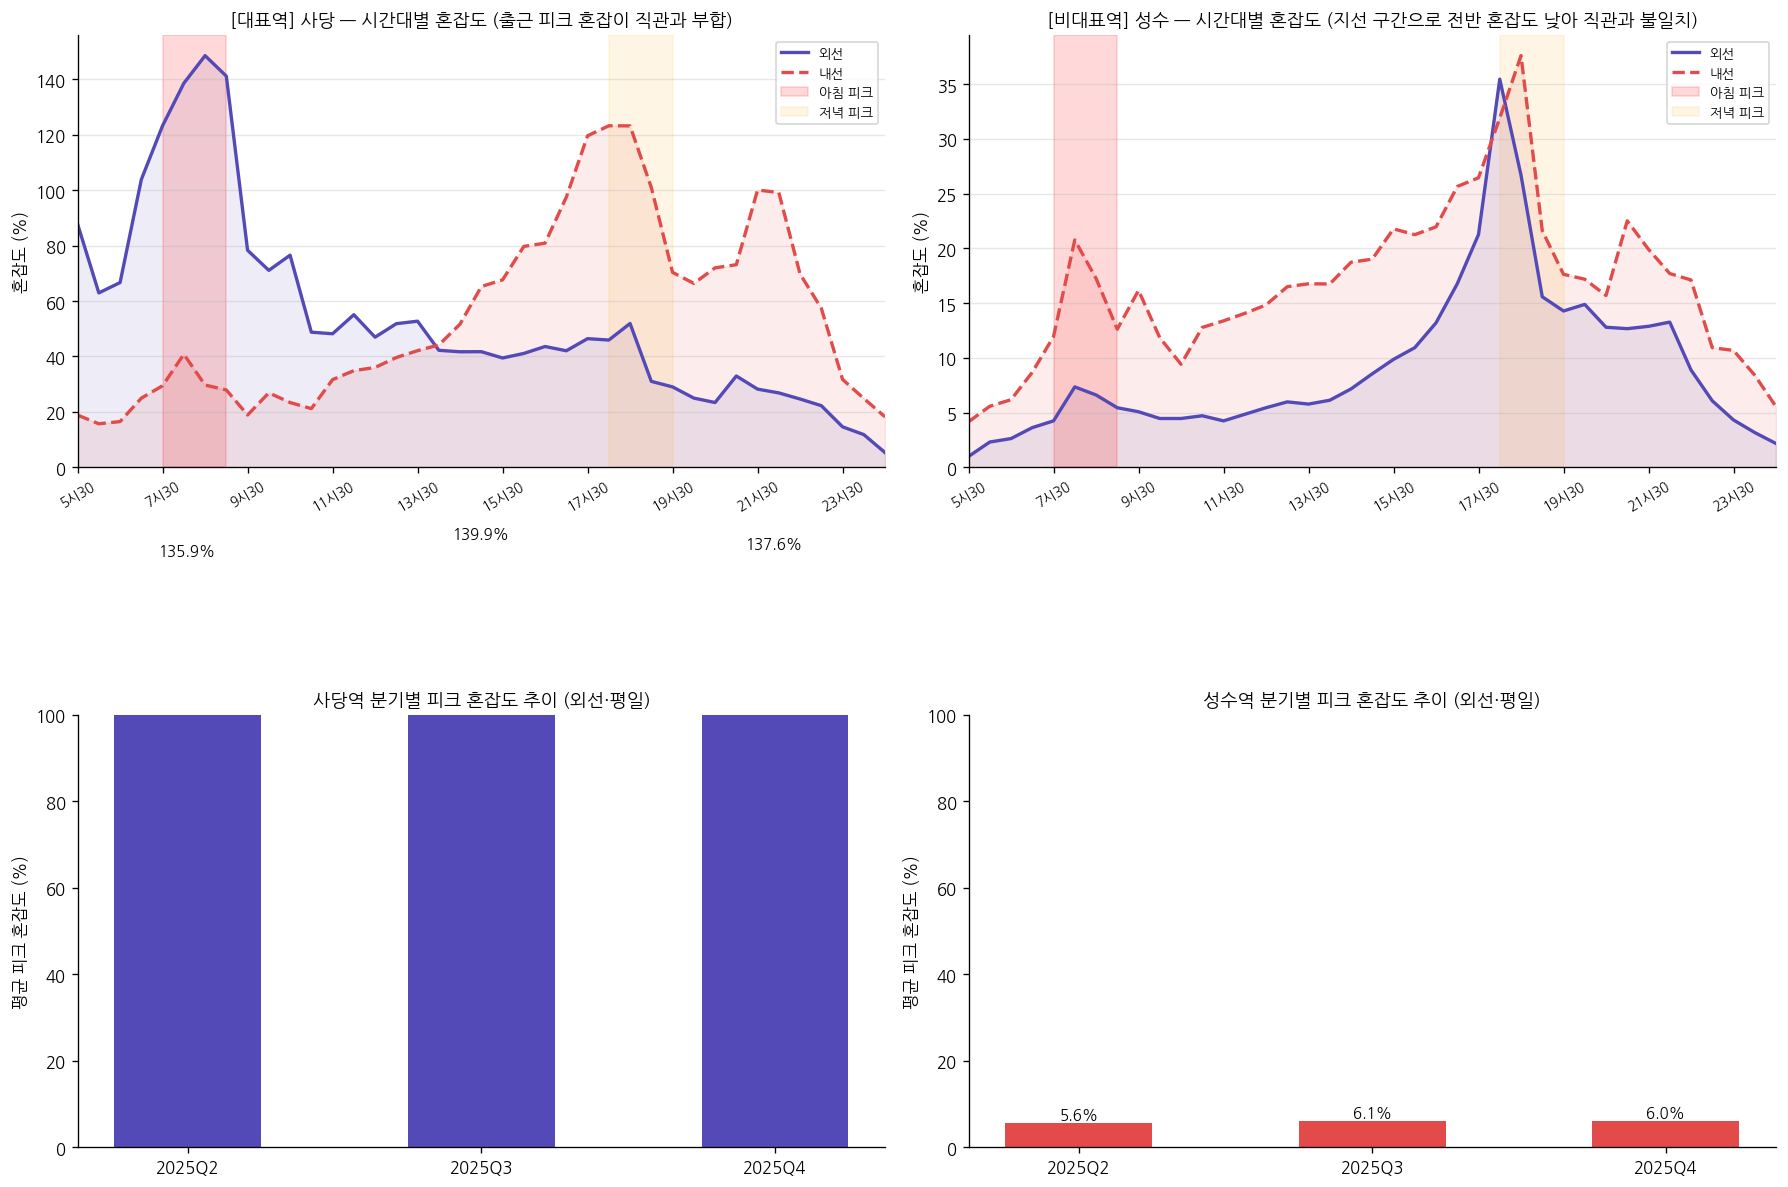

In [18]:
df_l2_wd = df_line2[df_line2['요일구분']=='평일'].copy()

# 상하구분 값 확인
print('상하구분 고유값:', df_line2['상하구분'].unique())

# 혼잡도 값 스케일 확인 후 자동 보정
sample_val = df_l2_wd[time_cols].stack().median()
print(f'혼잡도 중앙값 샘플: {sample_val:.4f}')
scale = 100 if sample_val < 2 else 1  # 0~1 범위면 100 곱하기
print(f'스케일 보정 배수: {scale}')

REP_STATION    = '사당'
NONREP_STATION = '성수'

# 외선=상선, 내선=하선
outer_key = '외선' if '외선' in df_line2['상하구분'].unique() else '상선'
inner_key = '내선' if '내선' in df_line2['상하구분'].unique() else '하선'

def get_station_profile(station):
    rows = df_l2_wd[df_l2_wd['출발역']==station]
    up   = rows[rows['상하구분']==outer_key][time_cols].mean() * scale
    down = rows[rows['상하구분']==inner_key][time_cols].mean() * scale
    return up, down

rep_up, rep_dn   = get_station_profile(REP_STATION)
nrep_up, nrep_dn = get_station_profile(NONREP_STATION)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

def plot_station(ax, up_vals, dn_vals, title):
    x = list(range(len(time_labels_full)))
    ax.plot(x, up_vals.values, label='외선', color='#534AB7', linewidth=2)
    ax.plot(x, dn_vals.values, label='내선', color='#E24B4A', linewidth=2, linestyle='--')
    ax.fill_between(x, up_vals.values, alpha=0.1, color='#534AB7')
    ax.fill_between(x, dn_vals.values, alpha=0.1, color='#E24B4A')
    pk_s = time_labels_full.index('7시30')
    pk_e = time_labels_full.index('9시00')
    ev_s = time_labels_full.index('18시00')
    ev_e = time_labels_full.index('19시30')
    ax.axvspan(pk_s, pk_e, alpha=0.15, color='red', label='아침 피크')
    ax.axvspan(ev_s, ev_e, alpha=0.1,  color='orange', label='저녁 피크')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('혼잡도 (%)')
    ax.set_xticks(range(0, len(time_labels_full), 4))
    ax.set_xticklabels(time_labels_full[::4], rotation=30, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(0, len(x)-1)
    ax.set_ylim(0)

plot_station(axes[0,0], rep_up, rep_dn,
             '[대표역] 사당 — 시간대별 혼잡도 (출근 피크 혼잡이 직관과 부합)')
plot_station(axes[0,1], nrep_up, nrep_dn,
             '[비대표역] 성수 — 시간대별 혼잡도 (지선 구간으로 전반 혼잡도 낮아 직관과 불일치)')

peak_cols_sub = ['7시30분','8시00분','8시30분','9시00분']

for station, ax in [(REP_STATION, axes[1,0]), (NONREP_STATION, axes[1,1])]:
    qdata = []
    for q in ['2025Q1','2025Q2','2025Q3','2025Q4']:
        sub = df_line2[(df_line2['분기']==q) & (df_line2['요일구분']=='평일') &
                       (df_line2['상하구분']==outer_key) & (df_line2['출발역']==station)]
        if len(sub):
            val = sub[peak_cols_sub].mean(axis=1).mean() * scale
            qdata.append({'분기':q, '피크혼잡도': val})
    if qdata:
        qdf = pd.DataFrame(qdata)
        color = '#534AB7' if station==REP_STATION else '#E24B4A'
        ax.bar(qdf['분기'], qdf['피크혼잡도'], color=color, width=0.5)
        ax.set_title(f'{station}역 분기별 피크 혼잡도 추이 (외선·평일)', fontsize=11)
        ax.set_ylabel('평균 피크 혼잡도 (%)')
        ax.set_ylim(0, 100)
        for bar, row in zip(ax.patches, qdf.itertuples()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                    f'{row.피크혼잡도:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

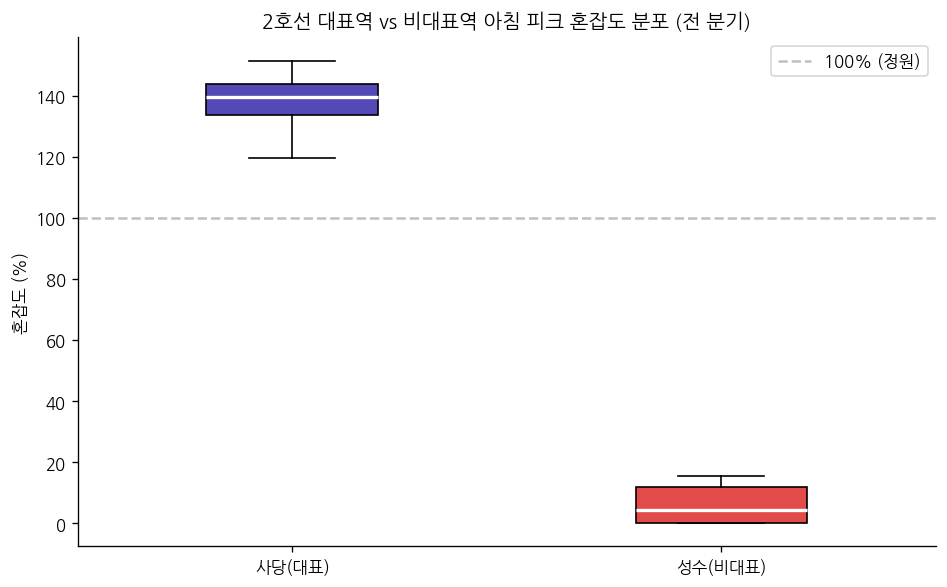

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

rep_rows  = df_line2[(df_line2['출발역']==REP_STATION)    & (df_line2['상하구분']==outer_key) & (df_line2['요일구분']=='평일')]
nrep_rows = df_line2[(df_line2['출발역']==NONREP_STATION) & (df_line2['상하구분']==outer_key) & (df_line2['요일구분']=='평일')]

rep_dist  = rep_rows[peak_cols_sub].values.flatten().astype(float) * scale
nrep_dist = nrep_rows[peak_cols_sub].values.flatten().astype(float) * scale
rep_dist  = rep_dist[~np.isnan(rep_dist)]
nrep_dist = nrep_dist[~np.isnan(nrep_dist)]

bp = ax.boxplot([rep_dist, nrep_dist],
                labels=[f'{REP_STATION}(대표)', f'{NONREP_STATION}(비대표)'],
                patch_artist=True, widths=0.4,
                medianprops={'color':'white','linewidth':2})
bp['boxes'][0].set_facecolor('#534AB7')
bp['boxes'][1].set_facecolor('#E24B4A')

ax.set_title('2호선 대표역 vs 비대표역 아침 피크 혼잡도 분포 (전 분기)', fontsize=12)
ax.set_ylabel('혼잡도 (%)')
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='100% (정원)')
ax.legend()
plt.tight_layout()
plt.show()

> 2호선 전체 역사 혼잡도 히트맵

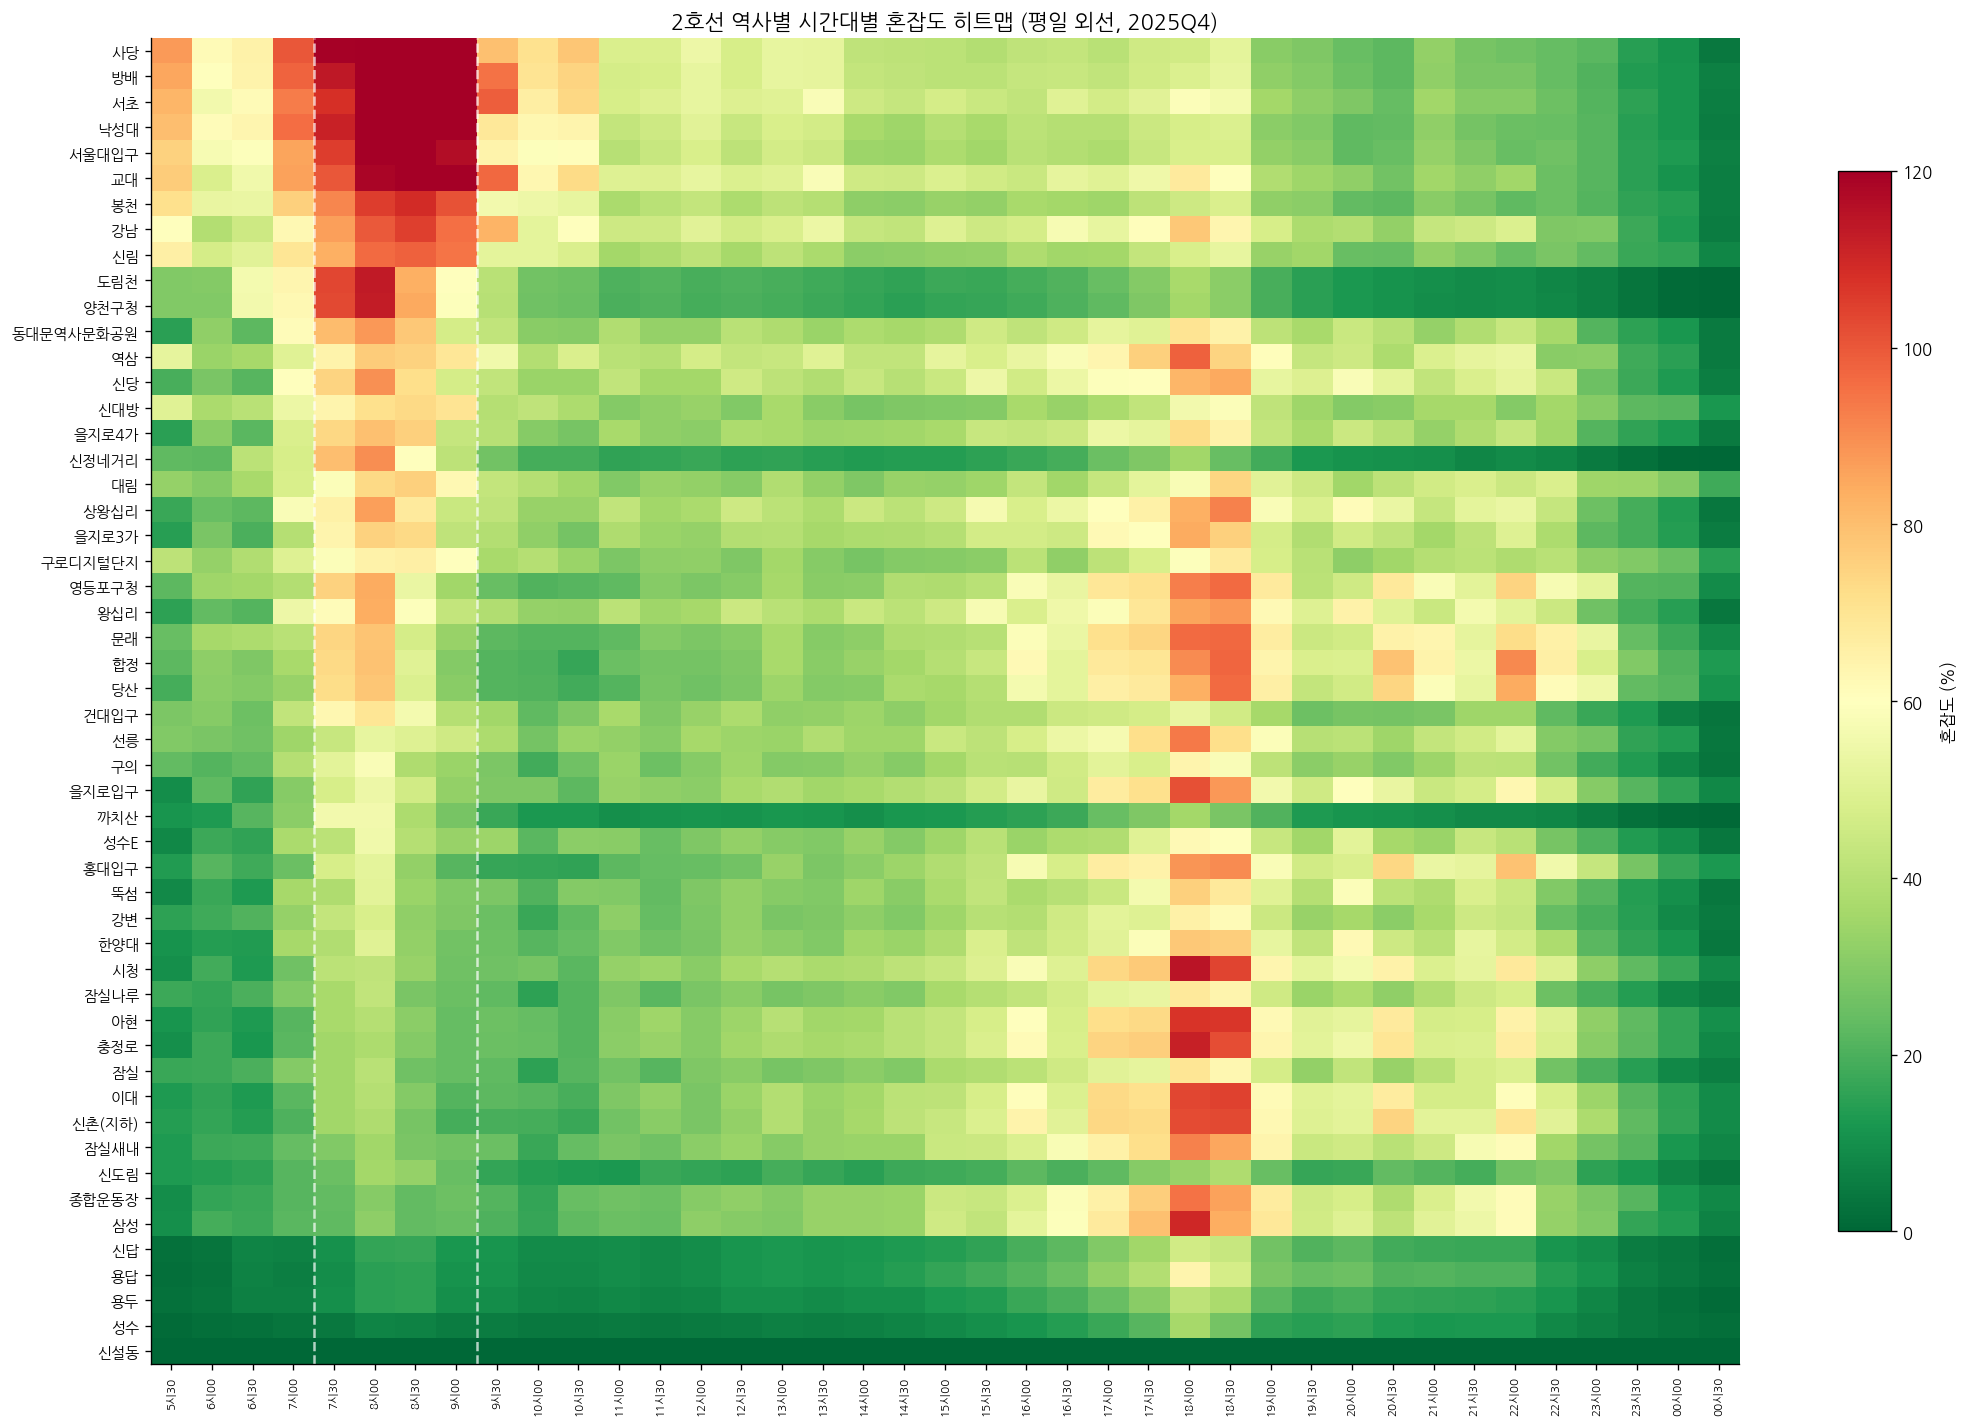

In [20]:
df_l2_q4_up = df_line2[
    (df_line2['분기']=='2025Q4') &
    (df_line2['요일구분']=='평일') &
    (df_line2['상하구분']==outer_key)   # '외선' 으로 필터
].copy()

heat_data = df_l2_q4_up.groupby('출발역')[time_cols].mean() * scale

peak_mean = heat_data[peak_cols_sub].mean(axis=1).sort_values(ascending=False)
heat_data = heat_data.loc[peak_mean.index]

fig, ax = plt.subplots(figsize=(18, 12))
cmap = plt.cm.RdYlGn_r
im = ax.imshow(heat_data.values, cmap=cmap, aspect='auto', vmin=0, vmax=120)

ax.set_xticks(range(len(time_cols)))
ax.set_xticklabels([c.replace('분','') for c in time_cols], rotation=90, fontsize=7)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=9)
ax.set_title('2호선 역사별 시간대별 혼잡도 히트맵 (평일 외선, 2025Q4)', fontsize=13)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('혼잡도 (%)')

pk_start = list(time_cols).index('7시30분')
pk_end   = list(time_cols).index('9시00분')
ax.axvline(pk_start - 0.5, color='white', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(pk_end   + 0.5, color='white', linewidth=1.5, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

> 2호선 역사 행정동 매핑 & 토지 3종 데이터 연계 확인

In [21]:
df_line2['행정동명'] = df_line2['출발역'].map(LINE2_DONG)

line2_dongs = set([dong for dong in LINE2_DONG.values() if pd.notna(dong)])

latest_dongs_work = set(df_work[df_work['기준_년분기_코드'] == latest_q_w]['행정동_코드_명'].unique())
latest_dongs_resi = set(df_resi[df_resi['기준_년분기_코드'] == latest_q_r]['행정동_코드_명'].unique())
latest_dongs_road = set(df_road[df_road['기준_년분기_코드'] == latest_q_d]['행정동_코드_명'].unique())

print(f"2호선이 경유하는 총 행정동 수: {len(line2_dongs)}개")
print("-" * 60)
print(f"{'역 매핑 행정동':<15} {'직장인구':^8} {'상주인구':^8} {'길단위인구':^10}")
print("-" * 60)

for dong in sorted(line2_dongs):
    w_check = 'O' if dong in latest_dongs_work else 'X'
    r_check = 'O' if dong in latest_dongs_resi else 'X'
    d_check = 'O' if dong in latest_dongs_road else 'X'
    print(f"{dong:<15} {w_check:^8} {r_check:^8} {d_check:^10}")

2호선이 경유하는 총 행정동 수: 46개
------------------------------------------------------------
역 매핑 행정동          직장인구     상주인구     길단위인구   
------------------------------------------------------------
구로3동               O        O         O     
구의1동               O        O         O     
구의3동               O        O         O     
낙성대동               O        O         O     
당산2동               O        O         O     
대림2동               O        O         O     
대학동                O        O         O     
대흥동                O        O         O     
도림동                O        O         O     
문래동                O        O         O     
방배본동               O        O         O     
사당1동               O        O         O     
삼성1동               O        O         O     
서교동                O        O         O     
서초1동               O        O         O     
서초3동               O        O         O     
성수1가1동             O        O         O     
성수1가2동             O        O         O     


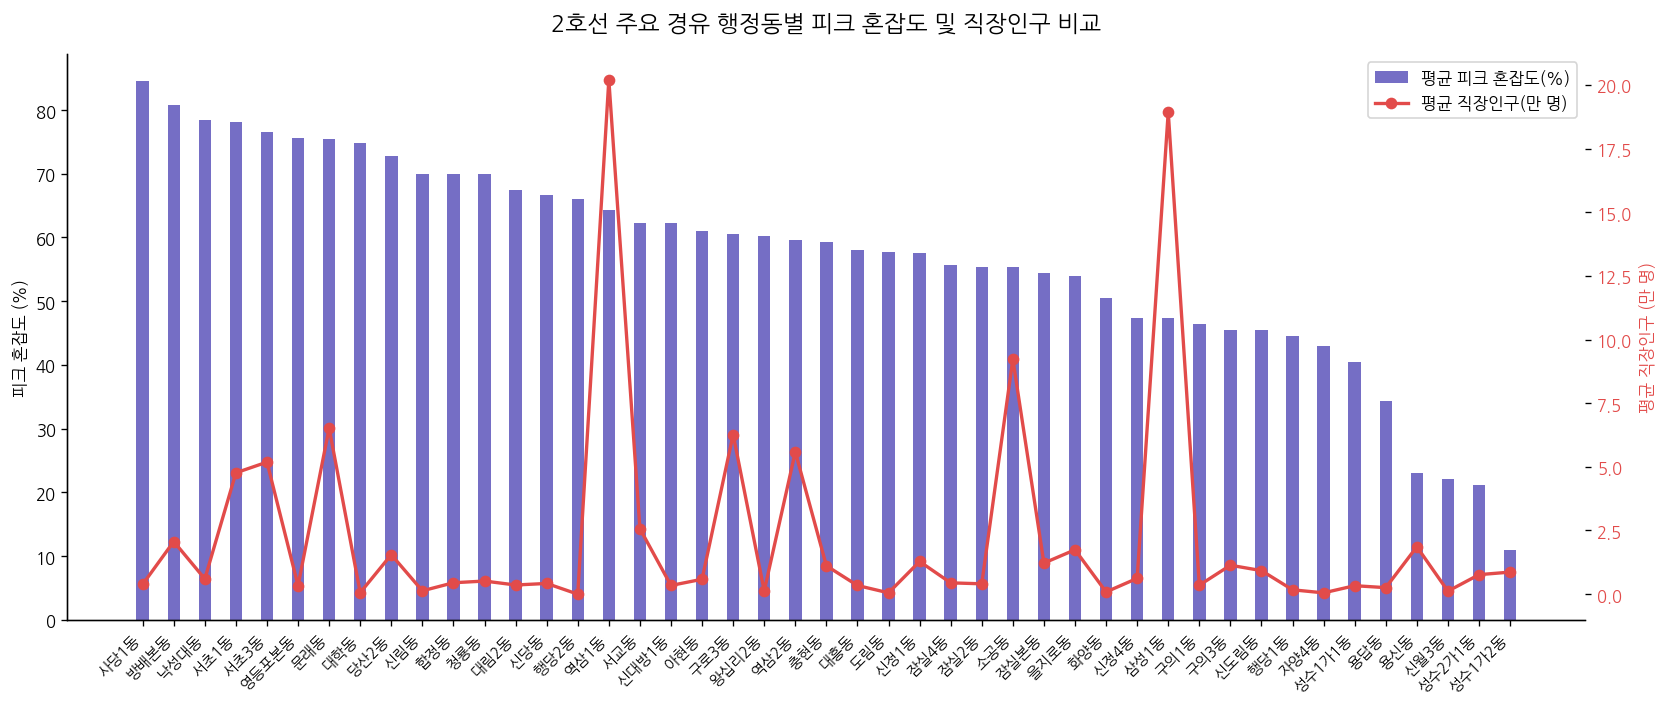

In [22]:
df_l2_q4_wd = df_line2[(df_line2['분기'] == '2025Q4') & (df_line2['요일구분'] == '평일')].copy()
df_l2_q4_wd['피크혼잡도'] = df_l2_q4_wd[peak_cols_sub].mean(axis=1)

cong_by_dong = df_l2_q4_wd.groupby('행정동명')['피크혼잡도'].mean().reset_index()

work_by_dong = df_work[df_work['기준_년분기_코드'] == latest_q_w].groupby('행정동_코드_명')['총_직장_인구_수'].mean().reset_index()

cong_by_dong.columns = ['행정동', '피크혼잡도']
work_by_dong.columns = ['행정동', '총_직장_인구_수']

merged = pd.merge(cong_by_dong, work_by_dong, on='행정동', how='left')
merged = merged.dropna().sort_values('피크혼잡도', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(merged))

ax.bar(x, merged['피크혼잡도'], color='#534AB7', width=0.4, label='평균 피크 혼잡도(%)', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(merged['행정동'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('피크 혼잡도 (%)')
ax.set_title(f'2호선 주요 경유 행정동별 피크 혼잡도 및 직장인구 비교', fontsize=14, pad=15)

ax2 = ax.twinx()
ax2.plot(x, merged['총_직장_인구_수'] / 1e4, 'o-', color='#E24B4A', linewidth=2, label='평균 직장인구(만 명)')
ax2.set_ylabel('평균 직장인구 (만 명)', color='#E24B4A')
ax2.tick_params(axis='y', labelcolor='#E24B4A')

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# Data Preprocessing

##  Work data
>   2025 이전 데이터 삭제

In [23]:
df_work = df_work[df_work['기준_년분기_코드'] >= 20251]



> 필요한 col 선택



In [24]:
cols_to_keep_work = ['기준_년분기_코드', '총_직장_인구_수', '행정동_코드_명']
df_work = df_work[cols_to_keep_work]

##  Residents data
>  2025 이전 데이터 삭제



In [25]:
df_resi = df_resi[df_resi['기준_년분기_코드'] >= 20251]

> 필요한 col 선택



In [26]:
cols_to_keep_resi = ['기준_년분기_코드', '총_상주인구_수', '행정동_코드_명']
df_resi = df_resi[cols_to_keep_resi]

## Road data
> 2025 이전 데이터 삭제


In [27]:
df_road = df_road[df_road['기준_년분기_코드'] >= 20251]

>   필요한 col 선택


In [28]:
cols_to_keep_road = ['기준_년분기_코드', '총_유동인구_수', '행정동_코드_명']
df_road = df_road[cols_to_keep_road]

##  Congestion data
> 분기 합치기



In [29]:
df_cong = pd.concat([df_q1, df_q2, df_q3, df_q4], ignore_index=True)
df_cong = df_cong[df_cong['호선'].isin(['2호선', '20호선'])]

>  신촌역 이름 통일



In [30]:
df_cong['출발역'] = df_cong['출발역'].replace('신촌(지하)', '신촌')



>   시간 통합 ( ex. 6시 + 6시 30분 = 6시 )



In [31]:
time_cols = [c for c in df_cong.columns if '시' in c and '분' in c]

df_quarterly_sum = df_cong.groupby(['분기', '출발역', '역번호', '상하구분'])[time_cols].mean().reset_index()

df_cong_mean = df_quarterly_sum.groupby(['출발역', '역번호', '상하구분'])[time_cols].mean().reset_index()

column_mapping = {col: '5시' if col == '5시30분' else col.split('시')[0] + '시' for col in time_cols}

df_cong_mapped = df_cong_mean.set_index(['출발역', '역번호', '상하구분'])\
                             .groupby(column_mapping, axis=1)\
                             .sum()\
                             .reset_index()

time_order = [f"{i}시" for i in range(5, 24)] + ['00시']
df_cong_final = df_cong_mapped[['출발역', '역번호', '상하구분'] + time_order]

> 지선 역번호 제거

In [32]:
BRANCH_STATION_NAMES = [
    '신답', '용답', '신설동', '도림천', '까치산', '신정네거리', '용두', '양천구청',
    '성수E', '상왕십리(지선)', '동대문역사문화공원(지선)'
]

df_cong_final = df_cong_final[~df_cong_final['출발역'].isin(BRANCH_STATION_NAMES)].reset_index(drop=True)

##    Data Integration

In [33]:
df_base = pd.DataFrame(list(LINE2_DONG.items()), columns=['출발역', '행정동_코드_명'])
df_sangkwon = df_work.merge(df_resi, on=['기준_년분기_코드', '행정동_코드_명'], how='outer')
df_sangkwon = df_sangkwon.merge(df_road, on=['기준_년분기_코드', '행정동_코드_명'], how='outer')

df_gu_population = df_sangkwon.groupby(['행정동_코드_명'])[['총_직장_인구_수', '총_상주인구_수', '총_유동인구_수']].mean().reset_index()

df_station_pop = df_base.merge(df_gu_population, on='행정동_코드_명', how='left')

df_final = pd.merge(df_station_pop, df_cong_final, on='출발역', how='inner')

> 출발역 제거

In [34]:
df_final = df_final.drop(columns=['출발역'])

##    Data Transformation

>  one-hot encoding  - 행정동명




In [35]:
df_encoded = pd.get_dummies(df_final['행정동_코드_명'], dtype=int)
df_final = pd.concat([df_final, df_encoded], axis=1)
df_final= df_final.drop(columns=['행정동_코드_명'])

> binary encoding: 외선 내선

In [36]:
df_final['상하구분'] = df_final['상하구분'].map({'내선': 1, '외선': 0})

>  Population Feature Transformation

In [37]:
df_final = df_final.copy()

df_final['총_인구_합산'] = df_final['총_상주인구_수'] + df_final['총_직장_인구_수'] + df_final['총_유동인구_수']

df_final['주거_인구_비율'] = df_final['총_상주인구_수'] / df_final['총_인구_합산']
df_final['직장_인구_비율'] = df_final['총_직장_인구_수'] / df_final['총_인구_합산']
df_final['관광_인구_비율'] = df_final['총_유동인구_수'] / df_final['총_인구_합산']

In [38]:
latest_r = df_resi['기준_년분기_코드'].max()
latest_w = df_work['기준_년분기_코드'].max()

resi_g = df_resi[df_resi['기준_년분기_코드']==latest_r]         .groupby('행정동_코드_명')['총_상주인구_수'].mean()
work_g = df_work[df_work['기준_년분기_코드']==latest_w]         .groupby('행정동_코드_명')['총_직장_인구_수'].mean()
road_g = df_road[df_road['기준_년분기_코드'].astype(str).str.startswith('2025')]         .groupby('행정동_코드_명')['총_유동인구_수'].mean()

dong_pop = pd.DataFrame({
    '상주인구': resi_g,
    '직장인구': work_g,
    '유동인구': road_g
}).reset_index().rename(columns={'행정동_코드_명':'행정동'})

station_pop = station_dong_df.merge(dong_pop, on='행정동', how='left')

for col, nc in [('상주인구','주거_norm'),('직장인구','직장_norm'),('유동인구','관광_norm')]:
    mn, mx = station_pop[col].min(), station_pop[col].max()
    station_pop[nc] = (station_pop[col] - mn) / (mx - mn)

total = station_pop['주거_norm'] + station_pop['직장_norm'] + station_pop['관광_norm']
station_pop['주거_ratio'] = station_pop['주거_norm'] / total
station_pop['직장_ratio'] = station_pop['직장_norm'] / total
station_pop['관광_ratio'] = station_pop['관광_norm'] / total

> output Binning

In [39]:
time_cols = [f"{i}시" for i in range(5, 24)] + ['00시']

labels = ['Low', 'Medium-Low', 'Medium-High', 'High']

for col in time_cols:
    df_final[f'{col}_등급'] = pd.qcut(df_final[col], q=4, labels=labels)

grade_cols = [f'{i}시_등급' for i in range(5, 24)] + ['00시_등급']

grade_map = {'Low' : 0, 'Medium-Low' : 1, 'Medium-High' : 2, 'High' : 3}

for col in time_cols:
   df_final[f'{col}_등급'] = df_final[f'{col}_등급'].map(grade_map)

## Feature Engineering

In [40]:
ratio_cols = ['주거_ratio', '직장_ratio', '관광_ratio']

min_len = min(len(df_final), len(station_pop))

for col in ratio_cols:
    if col in station_pop.columns:
        df_final.loc[:min_len-1, col] = station_pop[col].values[:min_len]

drop_candidates = ['주거_인구_비율', '직장_인구_비율', '관광_인구_비율']
existing_drops = [col for col in drop_candidates if col in df_final.columns]
if existing_drops:
    df_final = df_final.drop(columns=existing_drops)

df_final[ratio_cols] = df_final[ratio_cols].fillna(0)


In [41]:
feature_cols = ['역번호', '상하구분','주거_ratio','직장_ratio','관광_ratio']
grade_cols = [f'{i}시_등급' for i in range(5, 24)] + ['00시_등급']

df_long = df_final[feature_cols + grade_cols].melt(
    id_vars    = feature_cols,
    value_vars = grade_cols,
    var_name   = '시간대',
    value_name = '혼잡도_등급'
)

df_long['시간대'] = df_long['시간대'].str.replace('시_등급', '').astype(int)
df_long['시간대'] = df_long['시간대'].replace(0, 24)
df_long = df_long.sort_values(['역번호', '상하구분', '시간대']).reset_index(drop=True)

df_long = pd.merge(df_long, station_dong_df, on='역번호', how='left')

> cf. 피처 추가 검토 — 같은 행정동 공유 역 간 혼잡도 통계

> 같은 행정동에 매핑된 역들은 ratio 피처 값이 동일하게 부여됨.  
→ 해당 역들 간 실제 혼잡도 차이가 있는지 확인하여 피처 추가 필요성 검토.

In [42]:
dong_cnt      = df_long.groupby('행정동')['역번호'].nunique()
overlap_dongs = dong_cnt[dong_cnt >= 2].index.tolist()

print('=' * 55)
print('같은 행정동 공유 역 간 혼잡도 통계 비교')
print('=' * 55)

for dong in overlap_dongs:
    data     = df_long[df_long['행정동'] == dong]
    stations = sorted(data['역번호'].unique())
    print(f'\n#{dong}')

    avgs = []
    for sid in stations:
        # ★ 핵심: .astype(float) 또는 .astype(int)를 추가해 숫자로 변환합니다!
        s_data = data[data['역번호'] == sid]['혼잡도_등급'].astype(float)

        m, std, mn, mx = s_data.mean(), s_data.std(), s_data.min(), s_data.max()
        avgs.append(m)

        print(f'  [{sid}] | mean={m:.3f}  std={std:.3f}  min={int(mn)}  max={int(mx)}')

    print(f'  {"→ 역간 평균 차이":18s} | {max(avgs)-min(avgs):.3f}')


같은 행정동 공유 역 간 혼잡도 통계 비교

#신당동
  [205] | mean=2.025  std=0.698  min=1  max=3
  [206] | mean=2.375  std=0.628  min=1  max=3
  [9003] | mean=0.050  std=0.221  min=0  max=1
  → 역간 평균 차이         | 2.325

#역삼1동
  [221] | mean=2.150  std=0.864  min=1  max=3
  [222] | mean=2.250  std=0.899  min=1  max=3
  → 역간 평균 차이         | 0.100

#을지로동
  [202] | mean=1.800  std=0.791  min=0  max=3
  [203] | mean=1.625  std=0.705  min=0  max=3
  [204] | mean=1.675  std=0.730  min=0  max=3
  → 역간 평균 차이         | 0.175

#행당2동
  [207] | mean=2.250  std=0.742  min=1  max=3
  [9002] | mean=0.000  std=0.000  min=0  max=0
  → 역간 평균 차이         | 2.250


> 남은 categorical col -> numeric col

In [43]:
for col in df_long.columns:
    if df_long[col].dtype == 'object' or df_long[col].dtype.name == 'category':
        df_long[col] = df_long[col].astype(str)
        df_long[col] = df_long[col].fillna('Missing')

        le = LabelEncoder()
        df_long[col] = le.fit_transform(df_long[col])

> 남은 결측치 0 & 혼잡도 int로 fix

In [44]:
df_long = df_long.fillna(0)
df_long['혼잡도_등급'] = df_long['혼잡도_등급'].astype(int)

#  Modelling

> feature, target split

In [45]:
X = df_long.drop(columns=['혼잡도_등급', '역번호', '행정동'])
y = df_long['혼잡도_등급']

> Train/Test Split


In [46]:
groups = df_long['역번호']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
cv_folds = list(sgkf.split(X, y, groups=groups))

for k, (tr, te) in enumerate(cv_folds):
    overlap = set(groups.iloc[tr]) & set(groups.iloc[te])
    print(f'Fold {k}: train {len(tr)} / test {len(te)} | 역 중복 {len(overlap)}')

Fold 0: train 1440 / test 360 | 역 중복 0
Fold 1: train 1440 / test 360 | 역 중복 0
Fold 2: train 1440 / test 360 | 역 중복 0
Fold 3: train 1440 / test 360 | 역 중복 0
Fold 4: train 1440 / test 360 | 역 중복 0


In [47]:
# fold 0번 기준 train 인덱스 꺼내기
train_idx, test_idx = cv_folds[0]
X_train = X.iloc[train_idx]

print(X_train.columns.tolist())
print(X_train.shape)
print(X_train.head())

['상하구분', '주거_ratio', '직장_ratio', '관광_ratio', '시간대']
(1440, 5)
   상하구분  주거_ratio  직장_ratio  관광_ratio  시간대
0     0  0.108884  0.329979  0.561137    5
1     0  0.108884  0.329979  0.561137    6
2     0  0.108884  0.329979  0.561137    7
3     0  0.108884  0.329979  0.561137    8
4     0  0.108884  0.329979  0.561137    9


## Logistic Regression


In [48]:
X_lr = X.copy()
X_lr = X_lr.select_dtypes(include=[np.number])
X_lr = X_lr.fillna(0)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

lr_acc, lr_f1 = [], []

X_lr = X_lr.drop(columns=['관광_ratio']) # 다중공선성 제거

for tr, te in cv_folds:
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(X_lr.iloc[tr])
    X_te = scaler.transform(X_lr.iloc[te])

    lr.fit(X_tr, y.iloc[tr])
    pred = lr.predict(X_te)

    lr_acc.append(accuracy_score(y.iloc[te], pred))
    lr_f1.append(f1_score(y.iloc[te], pred, average='macro'))

lr_acc, lr_f1 = np.array(lr_acc), np.array(lr_f1)

print('=== Logistic Regression (Baseline) ===')
print(f'Accuracy : {lr_acc.mean():.4f} (±{lr_acc.std():.4f})')
print(f'Macro F1 : {lr_f1.mean():.4f} (±{lr_f1.std():.4f})')

=== Logistic Regression (Baseline) ===
Accuracy : 0.2783 (±0.0360)
Macro F1 : 0.2154 (±0.0414)


## Random Forest



In [49]:
rf = RandomForestClassifier(
    n_estimators = 200,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

rf_cv = cross_validate(rf, X, y, cv=cv_folds,
                       scoring=['accuracy', 'f1_macro'])

print('=== Random Forest (Main) ===')
print(f"Accuracy : {rf_cv['test_accuracy'].mean():.4f} (±{rf_cv['test_accuracy'].std():.4f})")
print(f"Macro F1 : {rf_cv['test_f1_macro'].mean():.4f} (±{rf_cv['test_f1_macro'].std():.4f})")

=== Random Forest (Main) ===
Accuracy : 0.3106 (±0.0514)
Macro F1 : 0.2951 (±0.0606)


## LightGBM

In [50]:
lgbm = lgb.LGBMClassifier(
    n_estimators = 200,
    class_weight = 'balanced',   # RF와 동일 조건
    random_state = 42,
)

lgbm_cv = cross_validate(lgbm, X, y, cv=cv_folds,
                         scoring=['accuracy', 'f1_macro'])

print('=== LightGBM (Boosting) ===')
print(f"Accuracy : {lgbm_cv['test_accuracy'].mean():.4f} (±{lgbm_cv['test_accuracy'].std():.4f})")
print(f"Macro F1 : {lgbm_cv['test_f1_macro'].mean():.4f} (±{lgbm_cv['test_f1_macro'].std():.4f})")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 146
[LightGBM] [Info] Number of data points in the train set: 1440, number of used features: 5
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 140
[LightGBM] [Info] Number of data points in the train set: 1440, number of used features: 5
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from sc

## 7. Validation (Parameter tuning)
메인 모델(RF)에 대해서만 실행


In [51]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', None],
}
rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    scoring='f1_macro',   # 튜닝의 선택 기준: macro F1
    cv=cv_folds,
    n_jobs=-1,
    refit=True
)
rf_gs.fit(X, y)

print('=== RF Grid Search ===')
print(f"기본 RF Accuracy : {rf_cv['test_accuracy'].mean():.4f}")
print(f"기본 RF macro F1 : {rf_cv['test_f1_macro'].mean():.4f}")
print(f"튜닝 best F1     : {rf_gs.best_score_:.4f}")
print(f"best params      : {rf_gs.best_params_}")

best_rf = rf_gs.best_estimator_

=== RF Grid Search ===
기본 RF Accuracy : 0.3106 (±0.0514)
기본 RF macro F1 : 0.2951
튜닝 best F1     : 0.2920
best params      : {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'n_estimators': 100}


#  Evaluation
##      Accuracy, Macro F1-score, MAE

In [52]:
print("=== 1. 평가지표 선정 & 성능평가 ===")

y_pred_cv = cross_val_predict(best_rf, X, y, cv=cv_folds, n_jobs=-1)

acc = accuracy_score(y, y_pred_cv)
f1_macro = f1_score(y, y_pred_cv, average='macro')
mae = mean_absolute_error(y, y_pred_cv)

print(f"Accuracy (정확도)     : {acc:.4f}")
print(f"Macro F1-Score       : {f1_macro:.4f}")
print(f"MAE (평균 거리 오차) : {mae:.4f}")

=== 1. 평가지표 선정 & 성능평가 ===
Accuracy (정확도)     : 0.3239
Macro F1-Score       : 0.3119
MAE (평균 거리 오차) : 1.1256


## Error Analysis

=== 2. 오차 분석 (Error Analysis) ===
전체 평가 데이터 수  : 1800개
양극단 치명적 오차 건수: 217개
치명적 오차율: 12.06%



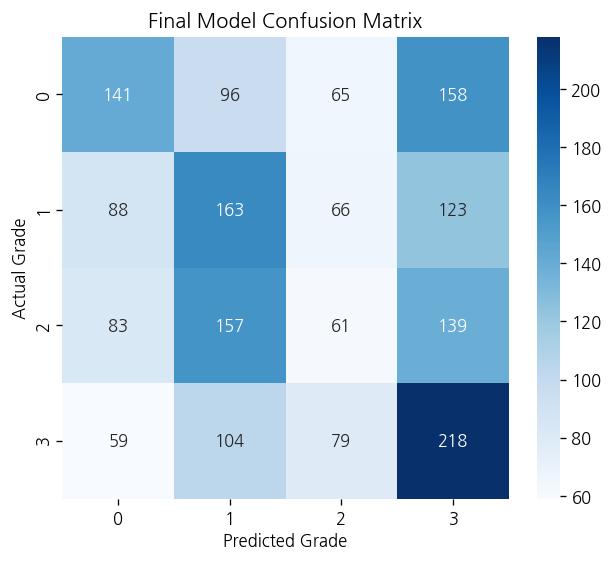

In [53]:
print("=== 2. 오차 분석 (Error Analysis) ===")

results = pd.DataFrame({'Actual': y, 'Predicted': y_pred_cv})
total_cases = len(results)

critical_errors = results[
    ((results['Actual'] == 3) & (results['Predicted'] == 0)) |
    ((results['Actual'] == 0) & (results['Predicted'] == 3))
]

critical_count = len(critical_errors)
critical_rate = (critical_count / total_cases) * 100

print(f"전체 평가 데이터 수  : {total_cases}개")
print(f"양극단 치명적 오차 건수: {critical_count}개")
print(f"치명적 오차율: {critical_rate:.2f}%\n")

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final Model Confusion Matrix')
plt.xlabel('Predicted Grade')
plt.ylabel('Actual Grade')
plt.show()

## Generalization validation -  (폴드 숫자 바꿔서 확인용)

In [54]:
print("=== 3. 일반화 성능 검증 (과적합 방지) ===")

# cv_folds의 첫 번째 세트 인덱스 가져오기
train_idx, test_idx = cv_folds[0]

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

# 최종 모델 파라미터로 해당 폴드 학습
eval_model = best_rf
eval_model.fit(X_train, y_train)

# Train 데이터와 Test 데이터 각각 예측 수행
pred_train = eval_model.predict(X_train)
pred_test = eval_model.predict(X_test)

train_f1 = f1_score(y_train, pred_train, average='macro')
test_f1 = f1_score(y_test, pred_test, average='macro')
score_diff = train_f1 - test_f1

print(f"Train Macro F1-Score : {train_f1:.4f}")
print(f"Test Macro F1-Score  : {test_f1:.4f}")
print(f"Score Drop (성능 차이) : {score_diff:.4f}\n")


=== 3. 일반화 성능 검증 (과적합 방지) ===
Train Macro F1-Score : 0.6429
Test Macro F1-Score  : 0.2025
Score Drop (성능 차이) : 0.4404



##Generalization validation - 5 fold

In [55]:
print("=== 3. 일반화 성능 검증 (전체 폴드 평균 확인) ===")

train_scores = []
test_scores = []

# 모든 교차검증 세트(Fold)를 하나씩 순회
for train_idx, test_idx in cv_folds:
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

    # 모델 학습 및 예측
    eval_model = best_rf
    eval_model.fit(X_train, y_train)

    pred_train = eval_model.predict(X_train)
    pred_test = eval_model.predict(X_test)

    # 각 폴드의 점수를 리스트에 저장
    train_scores.append(f1_score(y_train, pred_train, average='macro'))
    test_scores.append(f1_score(y_test, pred_test, average='macro'))

# 전체 폴드의 평균 점수 계산
avg_train_f1 = np.mean(train_scores)
avg_test_f1 = np.mean(test_scores)
avg_diff = avg_train_f1 - avg_test_f1

print(f"5개 폴드 평균 Train Macro F1 : {avg_train_f1:.4f}")
print(f"5개 폴드 평균 Test Macro F1  : {avg_test_f1:.4f}")
print(f"평균 Score Drop (성능 차이)    : {avg_diff:.4f}\n")


=== 3. 일반화 성능 검증 (전체 폴드 평균 확인) ===
5개 폴드 평균 Train Macro F1 : 0.6010
5개 폴드 평균 Test Macro F1  : 0.2920
평균 Score Drop (성능 차이)    : 0.3090



##  Feature Importance

=== 4. 모델 신뢰도 분석 (Feature Importance) ===


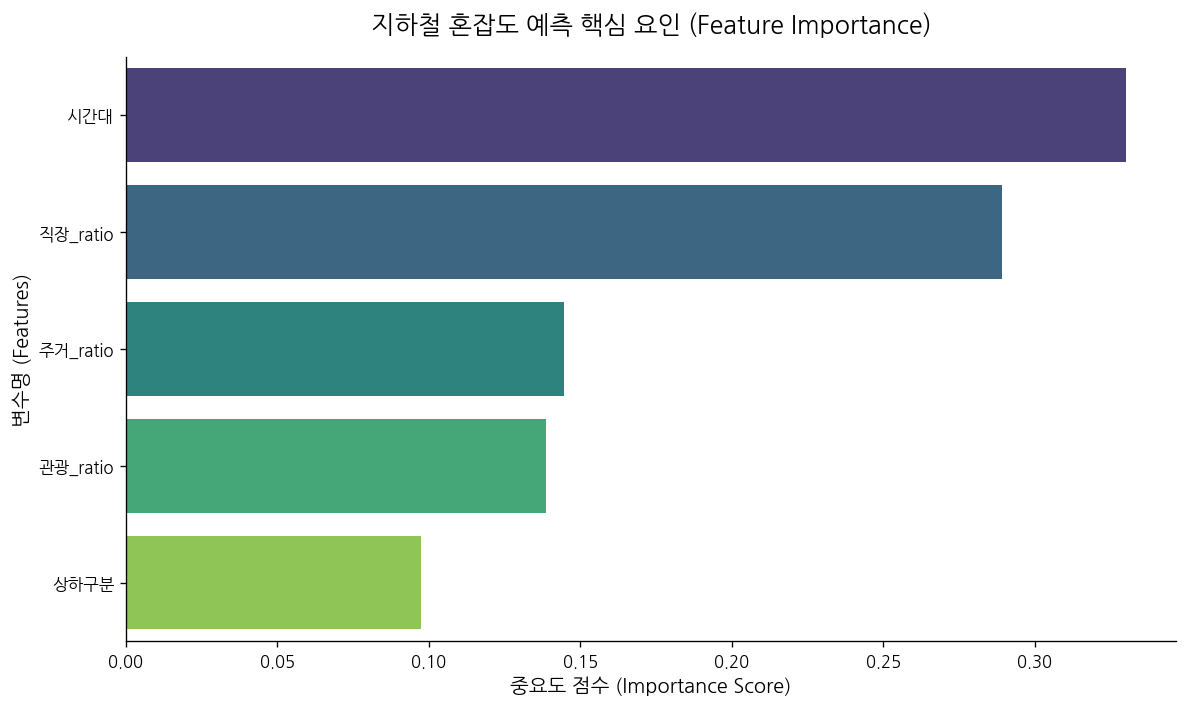


[지하철 혼잡도 예측 핵심 요인 Top 5]
1위: 시간대 (0.3301)
2위: 직장_ratio (0.2892)
3위: 주거_ratio (0.1445)
4위: 관광_ratio (0.1388)
5위: 상하구분 (0.0974)


In [56]:
print("=== 4. 모델 신뢰도 분석 (Feature Importance) ===")

importances = best_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')

plt.title('지하철 혼잡도 예측 핵심 요인 (Feature Importance)', fontsize=15, pad=15)
plt.xlabel('중요도 점수 (Importance Score)', fontsize=12)
plt.ylabel('변수명 (Features)', fontsize=12)

plt.tight_layout()
plt.show()

print("\n[지하철 혼잡도 예측 핵심 요인 Top 5]")
for i in range(min(5, len(indices))):
    print(f"{i+1}위: {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")